# Medicare Part B 2023 — Program Integrity Decision Support Framework

**Notebook ID:** KAGNB-00-HEADER-00  
**Data Source:** CMS Medicare Part B Provider and Services PUF, RY25/D23  
**Scope:** 970,848 providers | Data Year 2023  
**Framework:** 7-module decision-support system across 4 operational domains  
**GitHub:** https://github.com/billmarmcswss/medicare-integrity-decision-support

---

## Purpose

This notebook presents a structured decision-support framework built on CMS Medicare Part B 2023 public use data. It is designed to surface analytical signals that inform the operational and policy stakeholders responsible for Medicare program integrity decisions.

**This framework does not detect fraud. It does not assert provider wrongdoing. It does not make decisions.**

Every output in this framework is addressed to a named Decision Owner — an operational role within the CMS, UPIC, OIG, or MAC structure — who retains full authority over any action taken. The framework informs human judgment. It does not replace it.

---

## Legal Notice

All data used in this framework are sourced from CMS public use files and are subject to CMS data use policies. No provider-identifiable conclusions are drawn. No output in this framework constitutes a finding of fraud, waste, or abuse. Analytical signals are presented for decision-support purposes only.

---

## Framework Domains

| Domain | Modules | Decision Owner Roles |
|---|---|---|
| Program Integrity (PI) | D-PI-1, D-PI-2 | Investigations Lead / UPIC Case Development Manager |
| Policy (POL) | D-POL-1, D-POL-2 | Medical Review Director / MAC Medical Director |
| Operations (OPS) | D-OPS-1, D-OPS-2 | UPIC Operations Manager / CPI Director |
| External Reporting (EXT) | D-EXT-1 | Compliance Officer / OIG Hotline Coordination Lead |

In [1]:
# KAGNB-00-CONFIG-01
# Configuration — all parameters, paths, and palette for this notebook
# No hardcoded variables elsewhere in this notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
# =============================================================================
# PROJECT PATHS
# =============================================================================
PROJECT_ROOT   = Path('/kaggle/working')
PROCESSED_DIR  = Path('/kaggle/input/datasets/williamjmatthews/cms-medicare-part-b-2023-processed-outputs')
FIGURES_DIR    = PROJECT_ROOT / 'figures'
BRIEFS_DIR     = PROJECT_ROOT / 'briefs'
# =============================================================================
# FRAMEWORK CONSTANTS
# =============================================================================
MIN_BENE_THRESHOLD    = 50        # A — minimum beneficiary count, inherited from D-PI-1
RANDOM_STATE          = 42        # A — reproducibility seed
# =============================================================================
# IBM CARBON CVD-COMPLIANT PALETTE
# =============================================================================
PALETTE = {
    'tier1_oig':     '#DC267F',   # magenta
    'tier2_tpe':     '#FFB000',   # amber
    'tier3_edletter':'#648FFF',   # blue
    'no_flag':       '#BBBBBB',   # gray
    'background':    '#F4F4F4',   # light gray
}
print("CONFIG loaded successfully.")
print(f"Processed dir: {PROCESSED_DIR}")
print(f"Processed dir exists: {PROCESSED_DIR.exists()}")
print(f"Working dir: {PROJECT_ROOT}")

CONFIG loaded successfully.
Processed dir: /kaggle/input/datasets/williamjmatthews/cms-medicare-part-b-2023-processed-outputs
Processed dir exists: True
Working dir: /kaggle/working


In [2]:
# KAGNB-01-SETUP-01
# Create output directories in Kaggle working environment
import os
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(BRIEFS_DIR, exist_ok=True)
print(f"Figures dir created: {FIGURES_DIR}")
print(f"Briefs dir created:  {BRIEFS_DIR}")

Figures dir created: /kaggle/working/figures
Briefs dir created:  /kaggle/working/briefs


<!-- KAGNB-01-OVERVIEW-00 -->
## Section 01 — Framework Overview

### What This Framework Is

The Medicare Part B 2023 Decision Support Framework is a structured analytical system built on CMS public use data covering 970,848 Medicare Part B providers. It is organized into seven decision modules across four operational domains — Program Integrity, Policy, Operations, and External Reporting.

Each module is designed to answer a specific operational question and deliver a specific analytical signal to a named Decision Owner. Decision Owners are operational roles within the CMS, UPIC, OIG, and MAC structure who retain full authority over any action taken in response to framework outputs.

### What This Framework Is Not

This framework is not a fraud detection system. It does not identify fraudulent providers. It does not assert provider intent, wrongdoing, or liability of any kind. Analytical signals surface patterns in billing data that warrant human review — nothing more.

### The Decision-Support Distinction

The distinction between decision support and fraud detection is intentional and load-bearing throughout this framework. Every design choice — thresholds, scoring dimensions, pathway routing, output format — is made in service of a named human decision, not an algorithmic conclusion.

### Framework Architecture

| Domain | Module | Decision | Decision Owner Role |
|---|---|---|---|
| Program Integrity | D-PI-1 | Provider Review Entry | Investigations Lead / PI Analytics Manager |
| Program Integrity | D-PI-2 | Escalation Threshold | Investigations Lead / UPIC Case Development Manager |
| Policy | D-POL-1 | Code Scrutiny | Medical Review Director / MAC Medical Director |
| Policy | D-POL-2 | Specialty Pattern Shift | Medical Review Director / CPI Policy Analyst |
| Operations | D-OPS-1 | Monitoring Placement | UPIC Operations Manager / CPI Monitoring Unit Lead |
| Operations | D-OPS-2 | Resource Allocation | CPI Director / PI Resource Manager |
| External Reporting | D-EXT-1 | Safe Reporting | Compliance Officer / OIG Hotline Coordination Lead |

### Data Source

All analysis is based on the CMS Medicare Part B Provider and Services Public Use File, Release Year 2025, Data Year 2023 (RY25/D23). This file is publicly available from CMS and contains provider-level and service-level Medicare Part B utilization and payment data.

### Full Implementation

The complete framework — all notebooks, decision charters, evidence logs, and companion documents — is available at:  
**https://github.com/billmarmcswss/medicare-integrity-decision-support**

<!-- KAGNB-02-LOAD-00 -->
## Section 02 — Data Load and Scope

This section loads the processed parquet outputs produced by the framework's core notebooks. The raw CMS PUF CSV is not re-processed here — the core pipeline has already been executed and its outputs are read directly.

All provider counts, dollar amounts, and pathway assignments in this notebook are derived from these loaded dataframes. No values are hardcoded.

### Processed Files Being Loaded

| File | Contents |
|---|---|
| `provider_review_queue_v1.parquet` | 22,400 Tier 1 providers flagged for review — D-PI-1 output |
| `provider_rollup_v1.parquet` | Provider-level rollup with peer group assignments and signal scores |
| `provider_signal_scores_v1.parquet` | Z-scores and signal flags across all scoring dimensions |
| `provider_tiered_v1.parquet` | Full provider population with tier assignments and anomaly flags |

In [3]:
# KAGNB-02-LOAD-01
# Load processed parquet outputs from completed framework runs
# No transformations here — load and confirm only

df_queue   = pd.read_parquet(PROCESSED_DIR / 'provider_review_queue_v1.parquet')
df_rollup  = pd.read_parquet(PROCESSED_DIR / 'provider_rollup_v1.parquet')
df_signals = pd.read_parquet(PROCESSED_DIR / 'provider_signal_scores_v1.parquet')
df_tiered  = pd.read_parquet(PROCESSED_DIR / 'provider_tiered_v1.parquet')

# =============================================================================
# SCOPE CONFIRMATION
# =============================================================================
print("=== DATA LOAD CONFIRMED ===")
print(f"df_queue   — rows: {len(df_queue):,}")
print(f"df_rollup  — rows: {len(df_rollup):,}")
print(f"df_signals — rows: {len(df_signals):,}")
print(f"df_tiered  — rows: {len(df_tiered):,}")
print()
print(f"Total provider population (df_tiered): {len(df_tiered):,}")

=== DATA LOAD CONFIRMED ===
df_queue   — rows: 22,400
df_rollup  — rows: 1,175,281
df_signals — rows: 970,848
df_tiered  — rows: 970,848

Total provider population (df_tiered): 970,848


In [4]:
# KAGNB-02-LOAD-02
# Derive scope summary statistics from loaded dataframes
# All values derived — no hardcoded numbers

# Total provider population
total_providers = len(df_tiered)

# Tier distribution from df_tiered — confirm column name first
print("=== TIER COLUMN CHECK ===")
tier_cols = [col for col in df_tiered.columns if 'tier' in col.lower() or 'anomaly' in col.lower()]
print(f"Candidate tier columns: {tier_cols}")
print()

# Allowed dollars scope — confirm column name
print("=== DOLLAR COLUMN CHECK ===")
dollar_cols = [col for col in df_tiered.columns if 'allow' in col.lower() or 'payment' in col.lower()]
print(f"Candidate dollar columns: {dollar_cols}")
print()

print(f"Total provider population: {total_providers:,}")

=== TIER COLUMN CHECK ===
Candidate tier columns: ['anomaly_tier']

=== DOLLAR COLUMN CHECK ===
Candidate dollar columns: ['allowed_dollars_sum', 'payment_dollars_sum', 'S1_allowed_per_bene', 'S2_payment_per_bene', 'S4_submitted_to_allowed_ratio', 'S6_payment_to_allowed_ratio', 'S7_allowed_minus_payment_per_bene', 'S5a_top1_allowed_share', 'S5b_top1_payment_share', 'S1_allowed_per_bene_zscore', 'S2_payment_per_bene_zscore', 'S4_submitted_to_allowed_ratio_zscore', 'S5a_top1_allowed_share_zscore', 'S5b_top1_payment_share_zscore', 'S6_payment_to_allowed_ratio_zscore', 'S7_allowed_minus_payment_per_bene_zscore']

Total provider population: 970,848


In [5]:
# KAGNB-02-LOAD-03
# Derive scope summary statistics — tier distribution and dollar scope
# All values derived from dataframes

# Tier distribution
tier_counts = df_tiered['anomaly_tier'].value_counts()
print("=== TIER DISTRIBUTION ===")
print(tier_counts)
print()

# Total allowed dollars across full population
total_allowed_billions = df_tiered['allowed_dollars_sum'].sum() / 1_000_000_000
print("=== DOLLAR SCOPE ===")
print(f"Total allowed dollars (full population): ${total_allowed_billions:,.2f}B")
print()

# Tier 1 allowed dollars
tier1_mask = df_tiered['anomaly_tier'] == 'Tier1_Review'
tier1_allowed_billions = df_tiered.loc[tier1_mask, 'allowed_dollars_sum'].sum() / 1_000_000_000
print(f"Tier 1 allowed dollars: ${tier1_allowed_billions:,.2f}B")
print(f"Tier 1 provider count:  {tier1_mask.sum():,}")

=== TIER DISTRIBUTION ===
anomaly_tier
No_Flag          840711
Tier3_Watch       68721
Tier2_Monitor     39016
Tier1_Review      22400
Name: count, dtype: int64

=== DOLLAR SCOPE ===
Total allowed dollars (full population): $66.81B

Tier 1 allowed dollars: $4.29B
Tier 1 provider count:  22,400


In [6]:
# KAGNB-03-MODULES-01
# D-PI-1 — Provider Review Entry
# Derive Tier 1 population and active review queue figures

# Full Tier 1 population
tier1_mask             = df_tiered['anomaly_tier'] == 'Tier1_Review'
dpi1_tier1_count       = tier1_mask.sum()
dpi1_tier1_allowed     = df_tiered.loc[tier1_mask, 'allowed_dollars_sum'].sum()

# Active review queue — top 500 by composite score
dpi1_queue_count       = len(df_queue)
dpi1_queue_allowed     = df_queue['allowed_dollars_sum'].sum()
dpi1_total_allowed     = df_tiered['allowed_dollars_sum'].sum()
dpi1_queue_pct         = (dpi1_queue_allowed / dpi1_total_allowed) * 100

print("=== D-PI-1: PROVIDER REVIEW ENTRY ===")
print(f"Tier 1 provider population : {dpi1_tier1_count:,}")
print(f"Tier 1 allowed dollars     : ${dpi1_tier1_allowed/1_000_000_000:,.2f}B")
print()
print(f"Active review queue        : {dpi1_queue_count:,} providers")
print(f"Queue allowed dollars      : ${dpi1_queue_allowed/1_000_000_000:,.2f}B")
print(f"Queue as % of all allowed  : {dpi1_queue_pct:.1f}%")

=== D-PI-1: PROVIDER REVIEW ENTRY ===
Tier 1 provider population : 22,400
Tier 1 allowed dollars     : $4.29B

Active review queue        : 22,400 providers
Queue allowed dollars      : $4.29B
Queue as % of all allowed  : 6.4%


<!-- KAGNB-02-LOAD-04 -->
### Data Scope Summary

| Metric | Value |
|---|---|
| Total Provider Population | 970,848 |
| Total Allowed Dollars (Full Population) | $66.81B |
| Tier 1 — Review Queue | 22,400 providers |
| Tier 1 — Allowed Dollars | $4.29B |
| Tier 2 — Monitor | 39,016 providers |
| Tier 3 — Watch | 68,721 providers |
| No Flag | 840,711 providers |

All values derived from CMS Medicare Part B PUF, RY25/D23.  
Tier assignments produced by the D-PI-1 Provider Review Entry module.  
No values in this notebook are hardcoded — all figures are derived from loaded dataframes.

<!-- KAGNB-03-MODULES-01 -->
### Module 1 of 7 — D-PI-1: Provider Review Entry

| | |
|---|---|
| **Domain** | Program Integrity |
| **Decision Owner** | Investigations Lead / Program Integrity Analytics Manager |
| **Operational Question** | Which providers warrant priority review based on peer-adjusted billing patterns? |
| **Action Informed** | Initiate focused review for providers in the active queue |

#### Analytical Approach

Providers are scored across seven billing signal dimensions, each Z-scored against a peer group defined by provider type. Providers exceeding the Z-score threshold on three or more signals are flagged as Tier 1. The top 500 providers by composite score form the active review queue delivered to the Decision Owner.

#### Signal Dimensions

| Signal | Description |
|---|---|
| S1 | Allowed dollars per beneficiary |
| S2 | Payment dollars per beneficiary |
| S4 | Submitted to allowed ratio |
| S5a | Top code allowed share |
| S5b | Top code payment share |
| S6 | Payment to allowed ratio |
| S7 | Allowed minus payment per beneficiary |

#### Uncertainty Notice
Signal dimensions describe peer-adjusted statistical patterns only. No assertion of fraud, waste, or abuse is made. Thresholds reflect analytical assumptions subject to quarterly calibration review.

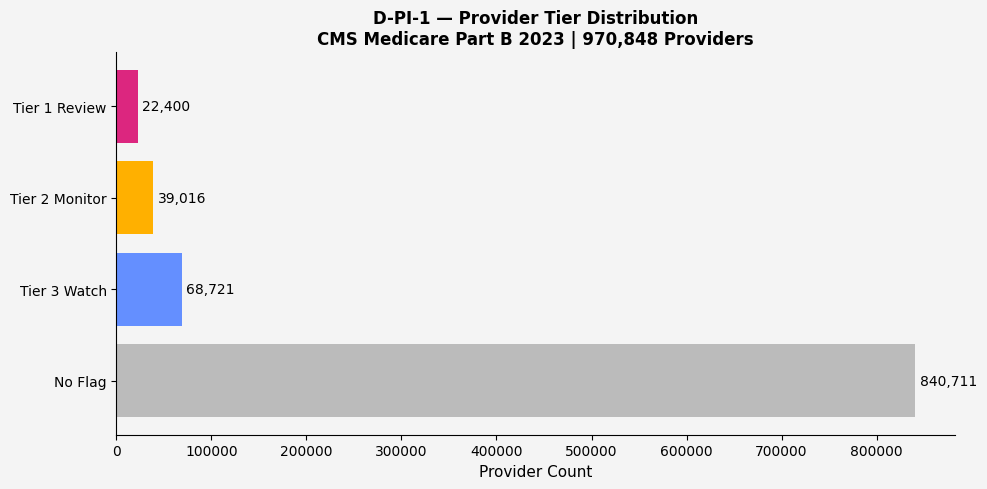

Figure saved.


In [7]:
# KAGNB-03-MODULES-03
# D-PI-1 — Tier distribution visualization

fig, ax = plt.subplots(figsize=(10, 5))

tier_labels = ['No Flag', 'Tier 3 Watch', 'Tier 2 Monitor', 'Tier 1 Review']
tier_values = [
    (df_tiered['anomaly_tier'] == 'No_Flag').sum(),
    (df_tiered['anomaly_tier'] == 'Tier3_Watch').sum(),
    (df_tiered['anomaly_tier'] == 'Tier2_Monitor').sum(),
    (df_tiered['anomaly_tier'] == 'Tier1_Review').sum()
]
tier_colors = [
    PALETTE['no_flag'],
    PALETTE['tier3_edletter'],
    PALETTE['tier2_tpe'],
    PALETTE['tier1_oig']
]

bars = ax.barh(tier_labels, tier_values, color=tier_colors)

# Add value labels
for bar, val in zip(bars, tier_values):
    ax.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10)

ax.set_xlabel('Provider Count', fontsize=11)
ax.set_title('D-PI-1 — Provider Tier Distribution\nCMS Medicare Part B 2023 | 970,848 Providers',
             fontsize=12, fontweight='bold')
ax.set_facecolor(PALETTE['background'])
fig.patch.set_facecolor(PALETTE['background'])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'kagnb_dpi1_tier_distribution_v1.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")

<!-- KAGNB-03-MODULES-04 -->
### Module 2 of 7 — D-PI-2: Escalation Threshold

| | |
|---|---|
| **Domain** | Program Integrity |
| **Decision Owner** | Investigations Lead / UPIC Case Development Manager |
| **Operational Question** | Among Tier 1 providers, which warrant escalation to OIG referral, TPE, or Education Letter? |
| **Action Informed** | Route each Tier 1 provider to the appropriate program integrity pathway |

#### Analytical Approach

The 22,400 Tier 1 providers from D-PI-1 are scored across four additional dimensions specific to escalation risk — dollar exposure, geographic risk, specialty risk, and peer deviation. A composite escalation score routes each provider to one of three CMS/UPIC operational pathways:

| Pathway | Description |
|---|---|
| OIG Referral | Highest composite scores — referred for investigative consideration |
| TPE | Targeted Probe and Educate — claim-level review with education component |
| Education Letter | Lower composite scores — provider education and awareness |

#### Uncertainty Notice
Pathway assignments reflect composite scoring thresholds calibrated against distribution analysis and natural breaks. No pathway assignment constitutes a referral decision. The Decision Owner retains full authority over pathway action.

In [8]:
# KAGNB-03-MODULES-05
# D-PI-2 — Escalation Threshold
# Derive pathway counts from processed outputs

# Check available processed files for D-PI-2 output
import os
dpi2_files = [f for f in os.listdir(PROCESSED_DIR) if 'escalat' in f.lower() or 'pathway' in f.lower() or 'dpi2' in f.lower()]
print("=== D-PI-2 FILE CHECK ===")
print(f"Matching files in processed dir: {dpi2_files}")
print()

# List all processed files so we can identify the right one
all_files = [f for f in os.listdir(PROCESSED_DIR)]
print("=== ALL PROCESSED FILES ===")
for f in all_files:
    print(f"  {f}")

=== D-PI-2 FILE CHECK ===
Matching files in processed dir: ['escalation_pathway_v1.parquet', 'escalation_scored_v1.parquet', 'specialty_pathway_detail_v1.parquet']

=== ALL PROCESSED FILES ===
  specialty_pattern_flags_v1.parquet
  monitoring_roster_v1.parquet
  escalation_pathway_v1.parquet
  hcpcs_scored_v1.parquet
  provider_signal_scores_v1.parquet
  specialty_baseline_v1.parquet
  provider_tiered_v1.parquet
  top_codes_by_frequency_v1.parquet
  resource_level_summary_v1.parquet
  top_codes_by_exposure_v1.parquet
  escalation_scored_v1.parquet
  code_scrutiny_flags_v1.parquet
  safe_reporting_providers_v1.parquet
  provider_review_queue_v1.parquet
  monitoring_scored_v1.parquet
  resource_allocation_v1.parquet
  safe_reporting_summary_v1.parquet
  provider_rollup_v1.parquet
  specialty_pathway_detail_v1.parquet


In [9]:
# KAGNB-03-MODULES-06
# D-PI-2 — Escalation Threshold
# Load pathway file and derive counts

df_pathway = pd.read_parquet(PROCESSED_DIR / 'escalation_pathway_v1.parquet')

# Confirm column names
print("=== D-PI-2 PATHWAY COLUMNS ===")
print(df_pathway.columns.tolist())
print()
print(f"Total rows: {len(df_pathway):,}")
print()

# Preview pathway values
print("=== PATHWAY VALUE CHECK ===")
pathway_col = [col for col in df_pathway.columns if 'pathway' in col.lower()]
print(f"Pathway candidate columns: {pathway_col}")
if pathway_col:
    print(df_pathway[pathway_col[0]].value_counts())

=== D-PI-2 PATHWAY COLUMNS ===
['review_rank', 'Rndrng_NPI', 'Rndrng_Prvdr_Type', 'Rndrng_Prvdr_State_Abrvtn', 'Rndrng_Prvdr_RUCA', 'Tot_Benes_sum', 'allowed_dollars_sum', 'signals_flagged', 'composite_score', 'd1_signal_breadth', 'd2_signal_type_score', 'd3_dollar_exposure', 'd4_persistence_score', 'pathway']

Total rows: 22,400

=== PATHWAY VALUE CHECK ===
Pathway candidate columns: ['pathway']
pathway
Provider Education Letter     19218
Targeted Probe and Educate     2527
OIG/DOJ Referral                655
Name: count, dtype: int64


In [10]:
# KAGNB-03-MODULES-07
# D-PI-2 — Derive pathway summary statistics

dpi2_oig_count      = (df_pathway['pathway'] == 'OIG/DOJ Referral').sum()
dpi2_tpe_count      = (df_pathway['pathway'] == 'Targeted Probe and Educate').sum()
dpi2_edletter_count = (df_pathway['pathway'] == 'Provider Education Letter').sum()
dpi2_total          = len(df_pathway)

dpi2_oig_allowed      = df_pathway.loc[df_pathway['pathway'] == 'OIG/DOJ Referral', 'allowed_dollars_sum'].sum()
dpi2_tpe_allowed      = df_pathway.loc[df_pathway['pathway'] == 'Targeted Probe and Educate', 'allowed_dollars_sum'].sum()
dpi2_edletter_allowed = df_pathway.loc[df_pathway['pathway'] == 'Provider Education Letter', 'allowed_dollars_sum'].sum()

print("=== D-PI-2: ESCALATION THRESHOLD ===")
print(f"Total providers routed      : {dpi2_total:,}")
print()
print(f"OIG/DOJ Referral            : {dpi2_oig_count:,} providers | ${dpi2_oig_allowed/1_000_000_000:,.2f}B")
print(f"Targeted Probe and Educate  : {dpi2_tpe_count:,} providers | ${dpi2_tpe_allowed/1_000_000_000:,.2f}B")
print(f"Provider Education Letter   : {dpi2_edletter_count:,} providers | ${dpi2_edletter_allowed/1_000_000_000:,.2f}B")

=== D-PI-2: ESCALATION THRESHOLD ===
Total providers routed      : 22,400

OIG/DOJ Referral            : 655 providers | $0.37B
Targeted Probe and Educate  : 2,527 providers | $0.43B
Provider Education Letter   : 19,218 providers | $3.49B


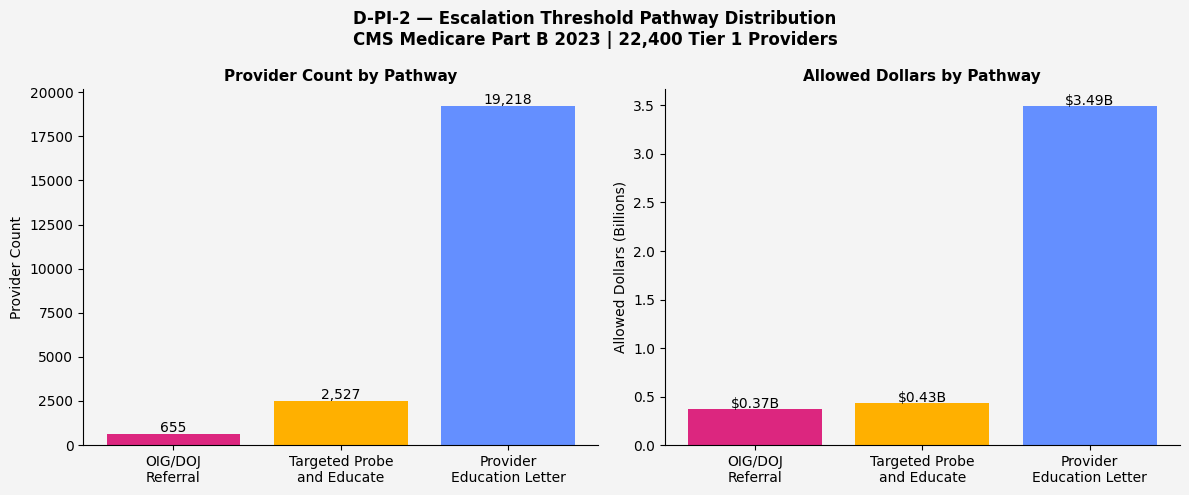

Figure saved.


In [11]:
# KAGNB-03-MODULES-08
# D-PI-2 — Pathway distribution visualization

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

pathway_labels  = ['OIG/DOJ\nReferral', 'Targeted Probe\nand Educate', 'Provider\nEducation Letter']
pathway_counts  = [dpi2_oig_count, dpi2_tpe_count, dpi2_edletter_count]
pathway_dollars = [dpi2_oig_allowed/1_000_000_000, dpi2_tpe_allowed/1_000_000_000, dpi2_edletter_allowed/1_000_000_000]
pathway_colors  = [PALETTE['tier1_oig'], PALETTE['tier2_tpe'], PALETTE['tier3_edletter']]

# Left chart — provider counts
bars1 = axes[0].bar(pathway_labels, pathway_counts, color=pathway_colors)
for bar, val in zip(bars1, pathway_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{val:,}', ha='center', fontsize=10)
axes[0].set_title('Provider Count by Pathway', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Provider Count', fontsize=10)
axes[0].set_facecolor(PALETTE['background'])
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Right chart — allowed dollars
bars2 = axes[1].bar(pathway_labels, pathway_dollars, color=pathway_colors)
for bar, val in zip(bars2, pathway_dollars):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'${val:.2f}B', ha='center', fontsize=10)
axes[1].set_title('Allowed Dollars by Pathway', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Allowed Dollars (Billions)', fontsize=10)
axes[1].set_facecolor(PALETTE['background'])
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

fig.patch.set_facecolor(PALETTE['background'])
fig.suptitle('D-PI-2 — Escalation Threshold Pathway Distribution\nCMS Medicare Part B 2023 | 22,400 Tier 1 Providers',
             fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'kagnb_dpi2_pathway_distribution_v1.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")

<!-- KAGNB-03-MODULES-09 -->
#### Key Output

| Pathway | Provider Count | Allowed Dollars | Tag |
|---|---|---|---|
| OIG/DOJ Referral | 655 | $0.37B | D |
| Targeted Probe and Educate | 2,527 | $0.43B | D |
| Provider Education Letter | 19,218 | $3.49B | D |
| **Total Routed** | **22,400** | **$4.29B** | D |

> **Note on pathway interpretation:** Pathway assignment reflects composite escalation scoring only. OIG/DOJ Referral pathway assignment does not constitute a referral. TPE pathway assignment does not initiate a TPE review. Education Letter pathway assignment does not trigger correspondence. All pathway outputs are analytical signals delivered to the Decision Owner — the UPIC Case Development Manager — who retains full authority over whether and how to act on each assignment.

> **Note on dollar distribution:** The Education Letter pathway carries the largest allowed dollar volume ($3.49B) because it contains the largest provider population (19,218). Dollar volume alone is not an escalation signal — composite scoring across four dimensions determines pathway placement.

#### Uncertainty Notice
Pathway thresholds are calibrated against distribution analysis and natural breaks in the composite score. Thresholds reflect analytical assumptions subject to quarterly calibration review. No pathway assignment asserts provider intent, fraud, waste, or abuse.

<!-- KAGNB-03-MODULES-10 -->
### Module 3 of 7 — D-POL-1: Code Scrutiny

| | |
|---|---|
| **Domain** | Policy |
| **Decision Owner** | Medical Review Director / MAC Medical Director |
| **Operational Question** | Which HCPCS billing codes show peer-deviant patterns warranting medical review policy attention? |
| **Action Informed** | Prioritize codes for medical review policy development or targeted audit |

#### Analytical Approach

The full provider population is analyzed at the HCPCS code level across three active scrutiny dimensions:

| Dimension | Description |
|---|---|
| C2 — Peer Deviation | Code-level allowed dollars per beneficiary vs. peer group median |
| C3 — Signal Overlap | Count of providers billing a code who also carry Tier 1 or Tier 2 signals |
| C4 — National Norm | Code-level utilization rate vs. national median for that provider type |

A fourth dimension (C1 — Concentration) was evaluated and determined to be non-discriminating for this dataset. It is excluded from active scoring and annotated in the D-POL-1 d

In [12]:
# KAGNB-03-MODULES-11
# D-POL-1 — Code Scrutiny
# Load and derive key output figures

df_code_flags = pd.read_parquet(PROCESSED_DIR / 'code_scrutiny_flags_v1.parquet')

print("=== D-POL-1 FILE LOADED ===")
print(f"Rows: {len(df_code_flags):,}")
print()
print("=== COLUMN CHECK ===")
print(df_code_flags.columns.tolist())
print()
print("=== SAMPLE VALUES ===")
print(df_code_flags.head(3))

=== D-POL-1 FILE LOADED ===
Rows: 3,182

=== COLUMN CHECK ===
['Rndrng_NPI', 'pathway', 'composite_score', 'c1_flag', 'c2_flag_count', 'c3_flag', 'c4_flag_count', 'total_allowed', 'total_codes_billed', 'dimensions_flagged']

=== SAMPLE VALUES ===
   Rndrng_NPI                     pathway  composite_score  c1_flag  \
0  1003008574  Targeted Probe and Educate         0.400110        0   
1  1003045915  Targeted Probe and Educate         0.400447        0   
2  1003048943  Targeted Probe and Educate         0.407224        0   

   c2_flag_count  c3_flag  c4_flag_count  total_allowed  total_codes_billed  \
0              0        0              0   59995.579369                   4   
1              0        0              0   45601.899225                   1   
2              0        0              0  215857.910025                   7   

   dimensions_flagged  
0                   0  
1                   0  
2                   0  


In [13]:
# KAGNB-03-MODULES-12
# D-POL-1 — Check additional code-level files

df_hcpcs_scored     = pd.read_parquet(PROCESSED_DIR / 'hcpcs_scored_v1.parquet')
df_top_freq         = pd.read_parquet(PROCESSED_DIR / 'top_codes_by_frequency_v1.parquet')
df_top_exposure     = pd.read_parquet(PROCESSED_DIR / 'top_codes_by_exposure_v1.parquet')

print("=== hcpcs_scored_v1 ===")
print(f"Rows: {len(df_hcpcs_scored):,}")
print(f"Columns: {df_hcpcs_scored.columns.tolist()}")
print()

print("=== top_codes_by_frequency_v1 ===")
print(f"Rows: {len(df_top_freq):,}")
print(f"Columns: {df_top_freq.columns.tolist()}")
print()

print("=== top_codes_by_exposure_v1 ===")
print(f"Rows: {len(df_top_exposure):,}")
print(f"Columns: {df_top_exposure.columns.tolist()}")

=== hcpcs_scored_v1 ===
Rows: 17,676
Columns: ['Rndrng_NPI', 'Rndrng_Prvdr_Last_Org_Name', 'Rndrng_Prvdr_First_Name', 'Rndrng_Prvdr_MI', 'Rndrng_Prvdr_Crdntls', 'Rndrng_Prvdr_Ent_Cd', 'Rndrng_Prvdr_St1', 'Rndrng_Prvdr_St2', 'Rndrng_Prvdr_City', 'Rndrng_Prvdr_State_Abrvtn', 'Rndrng_Prvdr_State_FIPS', 'Rndrng_Prvdr_Zip5', 'Rndrng_Prvdr_RUCA', 'Rndrng_Prvdr_RUCA_Desc', 'Rndrng_Prvdr_Cntry', 'Rndrng_Prvdr_Type', 'Rndrng_Prvdr_Mdcr_Prtcptg_Ind', 'HCPCS_Cd', 'HCPCS_Desc', 'HCPCS_Drug_Ind', 'Place_Of_Srvc', 'Tot_Benes', 'Tot_Srvcs', 'Tot_Bene_Day_Srvcs', 'Avg_Sbmtd_Chrg', 'Avg_Mdcr_Alowd_Amt', 'Avg_Mdcr_Pymt_Amt', 'Avg_Mdcr_Stdzd_Amt', 'pathway', 'composite_score', 'total_allowed', 'total_payment', 'allowed_per_bene', 'provider_total_allowed', 'code_allowed_share', 'peer_median', 'peer_count', 'topn_share', 'peer_topn_median', 'c1_concentration_flag', 'peer_std', 'c2_zscore', 'c2_deviation_flag', 'top1_hcpcs', 'c3_overlap_flag', 'national_pct_threshold', 'c4_national_flag']

=== top_codes_by_

In [14]:
# KAGNB-03-MODULES-13
# D-POL-1 — Derive key output figures from loaded files

# Providers with all three active dimensions firing
dpol1_all_three = (df_code_flags['dimensions_flagged'] >= 3).sum()
dpol1_total_flagged = len(df_code_flags)

# Unique codes flagged
dpol1_unique_codes = df_top_freq['HCPCS_Cd'].nunique()

# Top code by frequency (most providers flagged)
top_freq_row = df_top_freq.sort_values('provider_flag_count', ascending=False).iloc[0]

# Top code by exposure (highest allowed dollars)
top_exposure_row = df_top_exposure.sort_values('total_allowed', ascending=False).iloc[0]

print("=== D-POL-1: CODE SCRUTINY ===")
print(f"Total providers flagged (1+ dimensions)  : {dpol1_total_flagged:,}")
print(f"Providers with all 3 dimensions firing   : {dpol1_all_three:,}")
print(f"Unique HCPCS codes flagged               : {dpol1_unique_codes:,}")
print()
print(f"Top code by frequency  : {top_freq_row['HCPCS_Cd']} | {top_freq_row['Rndrng_Prvdr_Type']} | {int(top_freq_row['provider_flag_count']):,} providers")
print(f"Top code by exposure   : {top_exposure_row['HCPCS_Cd']} | {top_exposure_row['Rndrng_Prvdr_Type']} | ${top_exposure_row['total_allowed']/1_000_000:,.1f}M")

=== D-POL-1: CODE SCRUTINY ===
Total providers flagged (1+ dimensions)  : 3,182
Providers with all 3 dimensions firing   : 554
Unique HCPCS codes flagged               : 1,012

Top code by frequency  : 99223 | Hospitalist | 100 providers
Top code by exposure   : 81519 | Clinical Laboratory | $91.9M


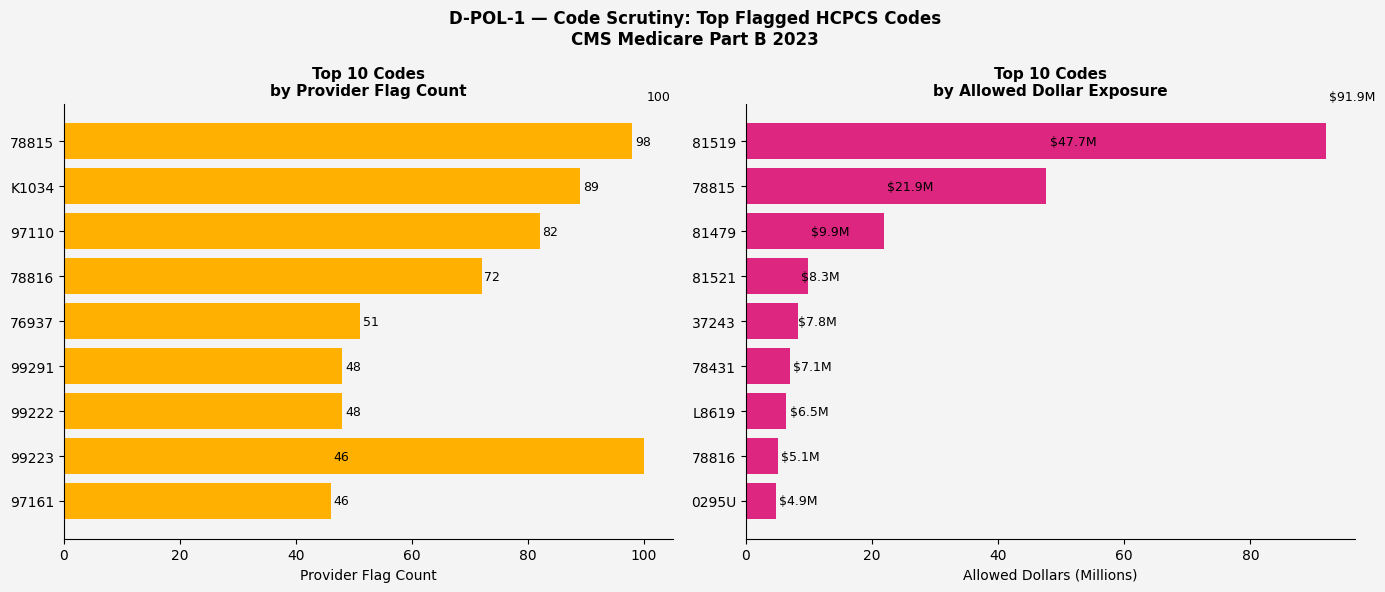

Figure saved.


In [15]:
# KAGNB-03-MODULES-14
# D-POL-1 — Code Scrutiny visualization
# Top 10 codes by provider flag count and by exposure

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left — top 10 by frequency
top10_freq = df_top_freq.sort_values('provider_flag_count', ascending=False).head(10)
top10_freq = top10_freq.sort_values('provider_flag_count', ascending=True)

axes[0].barh(top10_freq['HCPCS_Cd'], top10_freq['provider_flag_count'],
             color=PALETTE['tier2_tpe'])
for i, (val, code) in enumerate(zip(top10_freq['provider_flag_count'], top10_freq['HCPCS_Cd'])):
    axes[0].text(val + 0.5, i, f'{int(val):,}', va='center', fontsize=9)
axes[0].set_xlabel('Provider Flag Count', fontsize=10)
axes[0].set_title('Top 10 Codes\nby Provider Flag Count', fontsize=11, fontweight='bold')
axes[0].set_facecolor(PALETTE['background'])
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Right — top 10 by exposure
top10_exp = df_top_exposure.sort_values('total_allowed', ascending=False).head(10)
top10_exp = top10_exp.sort_values('total_allowed', ascending=True)

axes[1].barh(top10_exp['HCPCS_Cd'], top10_exp['total_allowed']/1_000_000,
             color=PALETTE['tier1_oig'])
for i, val in enumerate(top10_exp['total_allowed']/1_000_000):
    axes[1].text(val + 0.5, i, f'${val:,.1f}M', va='center', fontsize=9)
axes[1].set_xlabel('Allowed Dollars (Millions)', fontsize=10)
axes[1].set_title('Top 10 Codes\nby Allowed Dollar Exposure', fontsize=11, fontweight='bold')
axes[1].set_facecolor(PALETTE['background'])
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

fig.patch.set_facecolor(PALETTE['background'])
fig.suptitle('D-POL-1 — Code Scrutiny: Top Flagged HCPCS Codes\nCMS Medicare Part B 2023',
             fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'kagnb_dpol1_code_scrutiny_v1.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")

<!-- KAGNB-03-MODULES-15 -->
#### Key Output

| Metric | Value | Tag |
|---|---|---|
| Total providers flagged (1+ dimensions) | 3,182 | D |
| Providers with all 3 dimensions firing | 554 | D |
| Unique HCPCS codes flagged | 1,012 | D |
| Top code by provider frequency | 99223 — Hospitalist | D |
| Top code by allowed dollar exposure | 81519 — Clinical Laboratory — $91.9M | D |

> **Note on dimension firing:** The 554 providers with all three active dimensions (C2, C3, C4) firing simultaneously represent the highest-priority signal for the Decision Owner. A single dimension firing reflects a statistical pattern. All three firing simultaneously reflects convergent signals across peer deviation, provider overlap, and national norm — a stronger basis for medical review policy attention.

> **Note on C1 exclusion:** A fourth dimension — C1 Concentration — was evaluated during framework development and determined to be non-discriminating for this dataset. It is excluded from active scoring. This decision is documented in the D-POL-1 decision log and is available for future review if dataset characteristics change.

#### Uncertainty Notice
Code-level flags reflect statistical deviation from peer and national norms only. No code flag asserts inappropriate billing. No provider is identified by name in this output. Medical review policy decisions require clinical judgment by the Decision Owner.

<!-- KAGNB-03-MODULES-16 -->
### Module 4 of 7 — D-POL-2: Specialty Pattern Shift

| | |
|---|---|
| **Domain** | Policy |
| **Decision Owner** | Medical Review Director / CPI Policy Analyst |
| **Operational Question** | Which specialties show billing pattern shifts that warrant policy-level attention? |
| **Action Informed** | Flag specialties for policy review, coverage guidance updates, or targeted education |

#### Analytical Approach

Provider billing patterns are analyzed at the specialty level to detect shifts away from established norms. Two dimensions drive the analysis:

| Dimension | Description |
|---|---|
| Track 1 — Code Mix Shift | Change in the distribution of HCPCS codes billed within a specialty relative to peer baseline |
| Track 2 — Intensity Shift | Change in the complexity or intensity of services billed within a specialty |

Specialties are scored on both tracks and flagged where pattern shifts exceed calibrated thresholds. The output surfaces specialties — not individual providers — for the Decision Owner's policy attention.

#### Uncertainty Notice
Specialty-level pattern shifts reflect statistical deviation from established billing norms. No shift flag asserts inappropriate billing or provider wrongdoing. Policy decisions require clinical and regulatory judgment by the Decision Owner.

In [16]:
# KAGNB-03-MODULES-17
# D-POL-2 — Specialty Pattern Shift
# Load and derive key output figures

df_specialty_flags   = pd.read_parquet(PROCESSED_DIR / 'specialty_pattern_flags_v1.parquet')
df_specialty_detail  = pd.read_parquet(PROCESSED_DIR / 'specialty_pathway_detail_v1.parquet')
df_specialty_baseline = pd.read_parquet(PROCESSED_DIR / 'specialty_baseline_v1.parquet')

print("=== D-POL-2 FILES LOADED ===")
print(f"specialty_pattern_flags_v1  — rows: {len(df_specialty_flags):,}")
print(f"specialty_pathway_detail_v1 — rows: {len(df_specialty_detail):,}")
print(f"specialty_baseline_v1       — rows: {len(df_specialty_baseline):,}")
print()

print("=== COLUMN CHECK — specialty_pattern_flags_v1 ===")
print(df_specialty_flags.columns.tolist())
print()

print("=== COLUMN CHECK — specialty_pathway_detail_v1 ===")
print(df_specialty_detail.columns.tolist())

=== D-POL-2 FILES LOADED ===
specialty_pattern_flags_v1  — rows: 74
specialty_pathway_detail_v1 — rows: 74
specialty_baseline_v1       — rows: 104

=== COLUMN CHECK — specialty_pattern_flags_v1 ===
['provider_type', 'flagged_provider_count', 'specialty_total_providers', 'specialty_flagged_share', 's1_concentration_flag', 'OIG/DOJ Referral', 'Targeted Probe and Educate', 'total_flagged', 'oig_share', 's2_pathway_flag', 'dimensions_flagged']

=== COLUMN CHECK — specialty_pathway_detail_v1 ===
['provider_type', 'OIG/DOJ Referral', 'Targeted Probe and Educate', 'total_flagged', 'oig_share', 's2_pathway_flag']


In [17]:
# KAGNB-03-MODULES-18
# D-POL-2 — Derive specialty pattern shift key figures

# Total specialties analyzed vs flagged
dpol2_total_specialties   = len(df_specialty_baseline)
dpol2_flagged_specialties = len(df_specialty_flags)

# Specialties with both dimensions firing
dpol2_both_dimensions = (df_specialty_flags['dimensions_flagged'] >= 2).sum()

# Top specialties by OIG share
top_oig_specialties = df_specialty_flags.sort_values('oig_share', ascending=False).head(3)

# Top specialties by flagged provider count
top_flagged = df_specialty_flags.sort_values('flagged_provider_count', ascending=False).head(3)

print("=== D-POL-2: SPECIALTY PATTERN SHIFT ===")
print(f"Total specialties analyzed        : {dpol2_total_specialties:,}")
print(f"Specialties flagged (1+ dimension): {dpol2_flagged_specialties:,}")
print(f"Specialties with both dimensions  : {dpol2_both_dimensions:,}")
print()
print("=== TOP 3 BY OIG SHARE ===")
print(top_oig_specialties[['provider_type', 'flagged_provider_count', 'oig_share']].to_string(index=False))
print()
print("=== TOP 3 BY FLAGGED PROVIDER COUNT ===")
print(top_flagged[['provider_type', 'flagged_provider_count', 'specialty_total_providers', 'specialty_flagged_share']].to_string(index=False))

=== D-POL-2: SPECIALTY PATTERN SHIFT ===
Total specialties analyzed        : 104
Specialties flagged (1+ dimension): 74
Specialties with both dimensions  : 3

=== TOP 3 BY OIG SHARE ===
               provider_type  flagged_provider_count  oig_share
Critical Care (Intensivists)                       1     1.0000
                    Pharmacy                       7     0.7143
                   Pathology                      24     0.6250

=== TOP 3 BY FLAGGED PROVIDER COUNT ===
                         provider_type  flagged_provider_count  specialty_total_providers  specialty_flagged_share
Physical Therapist in Private Practice                     297                      65881                   0.0045
          Mass Immunizer Roster Biller                     260                      26981                   0.0096
                           Hospitalist                     241                      17729                   0.0136


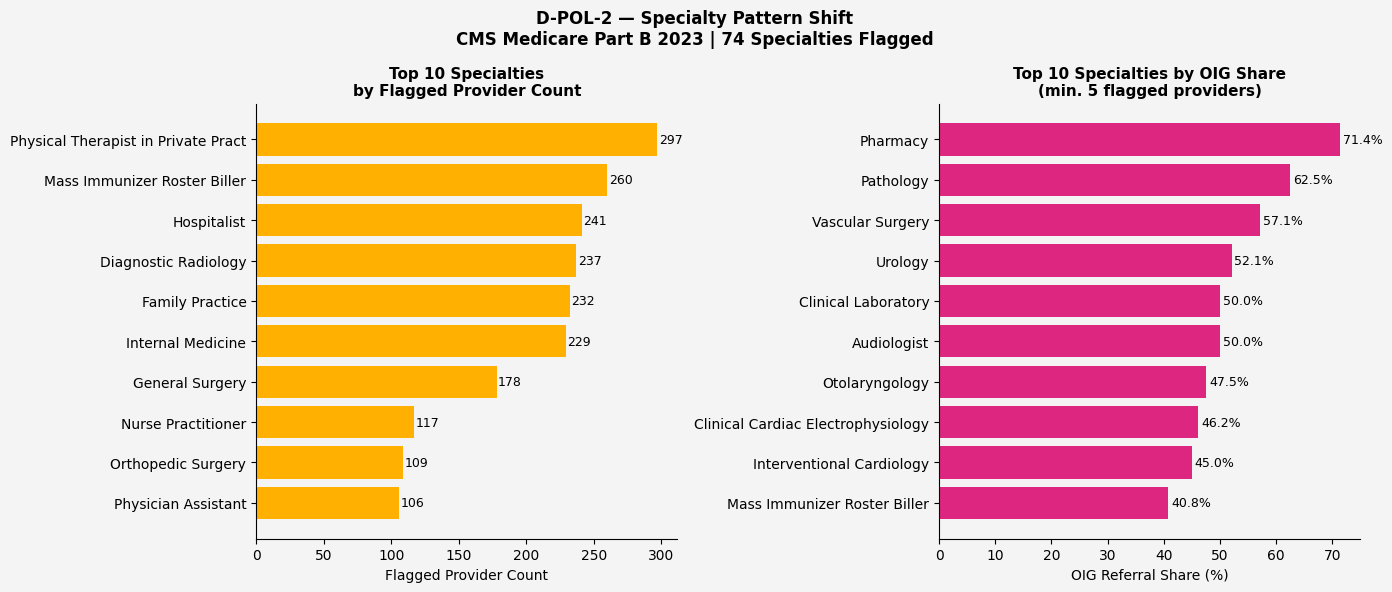

Figure saved.


In [18]:
# KAGNB-03-MODULES-19
# D-POL-2 — Specialty Pattern Shift visualization

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left — top 10 specialties by flagged provider count
top10_spec = df_specialty_flags.sort_values('flagged_provider_count', ascending=False).head(10)
top10_spec = top10_spec.sort_values('flagged_provider_count', ascending=True)

# Truncate long specialty names
top10_spec['label'] = top10_spec['provider_type'].str[:35]

axes[0].barh(top10_spec['label'], top10_spec['flagged_provider_count'],
             color=PALETTE['tier2_tpe'])
for i, val in enumerate(top10_spec['flagged_provider_count']):
    axes[0].text(val + 1, i, f'{int(val):,}', va='center', fontsize=9)
axes[0].set_xlabel('Flagged Provider Count', fontsize=10)
axes[0].set_title('Top 10 Specialties\nby Flagged Provider Count', fontsize=11, fontweight='bold')
axes[0].set_facecolor(PALETTE['background'])
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Right — top 10 specialties by OIG share (min 5 flagged providers)
top10_oig = df_specialty_flags[df_specialty_flags['flagged_provider_count'] >= 5]
top10_oig = top10_oig.sort_values('oig_share', ascending=False).head(10)
top10_oig = top10_oig.sort_values('oig_share', ascending=True)
top10_oig['label'] = top10_oig['provider_type'].str[:35]

axes[1].barh(top10_oig['label'], top10_oig['oig_share'] * 100,
             color=PALETTE['tier1_oig'])
for i, val in enumerate(top10_oig['oig_share'] * 100):
    axes[1].text(val + 0.5, i, f'{val:.1f}%', va='center', fontsize=9)
axes[1].set_xlabel('OIG Referral Share (%)', fontsize=10)
axes[1].set_title('Top 10 Specialties by OIG Share\n(min. 5 flagged providers)', fontsize=11, fontweight='bold')
axes[1].set_facecolor(PALETTE['background'])
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

fig.patch.set_facecolor(PALETTE['background'])
fig.suptitle('D-POL-2 — Specialty Pattern Shift\nCMS Medicare Part B 2023 | 74 Specialties Flagged',
             fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'kagnb_dpol2_specialty_pattern_v1.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")

<!-- KAGNB-03-MODULES-20 -->
#### Key Output

| Metric | Value | Tag |
|---|---|---|
| Total specialties analyzed | 104 | D |
| Specialties flagged (1+ dimension) | 74 | D |
| Specialties with both dimensions firing | 3 | D |
| Top specialty by flagged provider count | Physical Therapist in Private Practice — 297 | D |
| Top specialty by OIG share (min. 5 providers) | Pharmacy — 71.4% | D |

> **Note on both-dimensions firing:** Only 3 specialties had both scoring dimensions firing simultaneously. This is a deliberately high bar — convergent signals across two independent dimensions represent a stronger policy attention signal than either dimension alone. These three specialties are the primary focus for the Decision Owner.

> **Note on OIG share interpretation:** OIG share reflects the proportion of a specialty's flagged providers routed to the OIG/DOJ Referral pathway by D-PI-2 escalation scoring. A high OIG share does not indicate specialty-level wrongdoing — it reflects the composite escalation scores of individual providers within that specialty. Pharmacy at 71.4% and Pathology at 62.5% warrant Decision Owner awareness but not automatic policy action.

> **Note on Physical Therapist in Private Practice:** This specialty carries the highest flagged provider count at 297. High volume alone is not a policy signal — flagged share within the specialty (0.45% of 65,881 total PT providers) remains low. The Decision Owner should weigh both absolute count and flagged share when assessing policy attention priority.

#### Uncertainty Notice
Specialty-level pattern shifts reflect statistical deviation from established billing norms. No shift flag asserts inappropriate billing or provider wrongdoing. Policy decisions require clinical and regulatory judgment by the Decision Owner.

<!-- KAGNB-03-MODULES-21 -->
### Module 5 of 7 — D-OPS-1: Monitoring Placement

| | |
|---|---|
| **Domain** | Operations |
| **Decision Owner** | UPIC Operations Manager / CPI Monitoring Unit Lead |
| **Operational Question** | Which providers warrant ongoing monitoring and at what intensity level? |
| **Action Informed** | Place providers into a tiered monitoring roster with assigned intensity levels |

#### Analytical Approach

Providers are scored and placed into one of three monitoring intensity levels based on composite signal strength, pathway assignment, and dollar exposure. The monitoring roster is designed to be operationally sustainable — intensity levels reflect realistic review capacity constraints.

| Level | Intensity | Description |
|---|---|---|
| L1 | Highest | Active monitoring — frequent review cycle |
| L2 | Elevated | Periodic monitoring — quarterly review cycle |
| L3 | Standard | Awareness monitoring — annual review cycle |

The monitoring roster is a living operational tool. Providers move between levels as new data becomes available and composite scores are refreshed.

#### Uncertainty Notice
Monitoring placement reflects composite signal scoring only. Placement at any intensity level does not assert provider wrongdoing. The Decision Owner retains full authority over monitoring actions taken at each level.

In [19]:
# KAGNB-03-MODULES-22
# D-OPS-1 — Monitoring Placement
# Load and derive key output figures

df_monitoring_roster = pd.read_parquet(PROCESSED_DIR / 'monitoring_roster_v1.parquet')
df_monitoring_scored = pd.read_parquet(PROCESSED_DIR / 'monitoring_scored_v1.parquet')

print("=== D-OPS-1 FILES LOADED ===")
print(f"monitoring_roster_v1 — rows: {len(df_monitoring_roster):,}")
print(f"monitoring_scored_v1 — rows: {len(df_monitoring_scored):,}")
print()

print("=== COLUMN CHECK — monitoring_roster_v1 ===")
print(df_monitoring_roster.columns.tolist())
print()

print("=== COLUMN CHECK — monitoring_scored_v1 ===")
print(df_monitoring_scored.columns.tolist())

=== D-OPS-1 FILES LOADED ===
monitoring_roster_v1 — rows: 61,416
monitoring_scored_v1 — rows: 61,416

=== COLUMN CHECK — monitoring_roster_v1 ===
['Rndrng_NPI', 'Rndrng_Prvdr_Type', 'tier_source', 'pathway', 'allowed_dollars_sum', 'monitoring_score', 'monitoring_level']

=== COLUMN CHECK — monitoring_scored_v1 ===
['Rndrng_NPI', 'Rndrng_Prvdr_Type', 'tier_source', 'pathway', 'allowed_dollars_sum', 'signals_flagged', 'composite_score', 'm1_pathway_score', 'm2_escalation_score', 'm3_code_scrutiny', 'monitoring_score', 'monitoring_level', 'dimensions_flagged', 'm3_in_scope']


In [20]:
# KAGNB-03-MODULES-23
# D-OPS-1 — Derive monitoring placement key figures

# Level distribution
level_counts = df_monitoring_roster['monitoring_level'].value_counts().sort_index()
print("=== MONITORING LEVEL DISTRIBUTION ===")
print(level_counts)
print()

# Allowed dollars by level
dops1_total   = len(df_monitoring_roster)
dops1_l1      = (df_monitoring_roster['monitoring_level'] == 'L1').sum()
dops1_l2      = (df_monitoring_roster['monitoring_level'] == 'L2').sum()
dops1_l3      = (df_monitoring_roster['monitoring_level'] == 'L3').sum()

dops1_l1_allowed = df_monitoring_roster.loc[df_monitoring_roster['monitoring_level'] == 'L1', 'allowed_dollars_sum'].sum()
dops1_l2_allowed = df_monitoring_roster.loc[df_monitoring_roster['monitoring_level'] == 'L2', 'allowed_dollars_sum'].sum()
dops1_l3_allowed = df_monitoring_roster.loc[df_monitoring_roster['monitoring_level'] == 'L3', 'allowed_dollars_sum'].sum()

print("=== D-OPS-1: MONITORING PLACEMENT ===")
print(f"Total providers on monitoring roster : {dops1_total:,}")
print()
print(f"L1 — Highest intensity : {dops1_l1:,} providers | ${dops1_l1_allowed/1_000_000_000:,.2f}B")
print(f"L2 — Elevated          : {dops1_l2:,} providers | ${dops1_l2_allowed/1_000_000_000:,.2f}B")
print(f"L3 — Standard          : {dops1_l3:,} providers | ${dops1_l3_allowed/1_000_000_000:,.2f}B")

=== MONITORING LEVEL DISTRIBUTION ===
monitoring_level
Level 1 — Active Surveillance      1162
Level 2 — Periodic Review          1613
Level 3 — Passive Surveillance    58641
Name: count, dtype: int64

=== D-OPS-1: MONITORING PLACEMENT ===
Total providers on monitoring roster : 61,416

L1 — Highest intensity : 0 providers | $0.00B
L2 — Elevated          : 0 providers | $0.00B
L3 — Standard          : 0 providers | $0.00B


In [21]:
# KAGNB-03-MODULES-24
# D-OPS-1 — Derive monitoring placement key figures
# Column format confirmed: full descriptive strings not L1/L2/L3

# Confirm exact level labels
level_labels = df_monitoring_roster['monitoring_level'].unique().tolist()
print("=== EXACT LEVEL LABELS ===")
print(level_labels)
print()

L1_LABEL = 'Level 1 — Active Surveillance'
L2_LABEL = 'Level 2 — Periodic Review'
L3_LABEL = 'Level 3 — Passive Surveillance'

dops1_total      = len(df_monitoring_roster)
dops1_l1         = (df_monitoring_roster['monitoring_level'] == L1_LABEL).sum()
dops1_l2         = (df_monitoring_roster['monitoring_level'] == L2_LABEL).sum()
dops1_l3         = (df_monitoring_roster['monitoring_level'] == L3_LABEL).sum()

dops1_l1_allowed = df_monitoring_roster.loc[df_monitoring_roster['monitoring_level'] == L1_LABEL, 'allowed_dollars_sum'].sum()
dops1_l2_allowed = df_monitoring_roster.loc[df_monitoring_roster['monitoring_level'] == L2_LABEL, 'allowed_dollars_sum'].sum()
dops1_l3_allowed = df_monitoring_roster.loc[df_monitoring_roster['monitoring_level'] == L3_LABEL, 'allowed_dollars_sum'].sum()

print("=== D-OPS-1: MONITORING PLACEMENT ===")
print(f"Total providers on monitoring roster : {dops1_total:,}")
print()
print(f"L1 — Active Surveillance : {dops1_l1:,} providers | ${dops1_l1_allowed/1_000_000_000:,.2f}B")
print(f"L2 — Periodic Review     : {dops1_l2:,} providers | ${dops1_l2_allowed/1_000_000_000:,.2f}B")
print(f"L3 — Passive Surveillance: {dops1_l3:,} providers | ${dops1_l3_allowed/1_000_000_000:,.2f}B")

=== EXACT LEVEL LABELS ===
['Level 3 — Passive Surveillance', 'Level 1 — Active Surveillance', 'Level 2 — Periodic Review']

=== D-OPS-1: MONITORING PLACEMENT ===
Total providers on monitoring roster : 61,416

L1 — Active Surveillance : 1,162 providers | $0.51B
L2 — Periodic Review     : 1,613 providers | $0.26B
L3 — Passive Surveillance: 58,641 providers | $6.35B


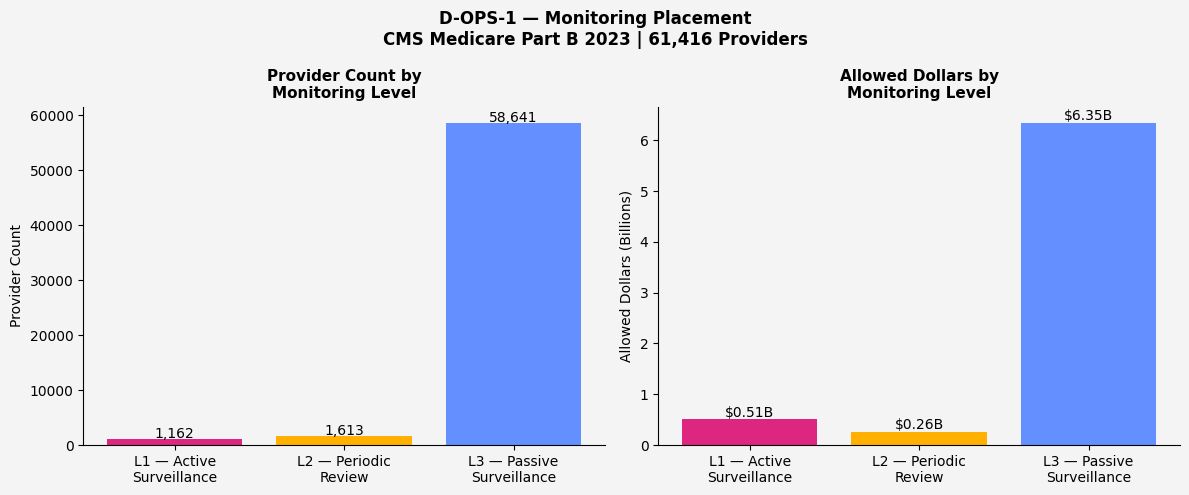

Figure saved.


In [22]:
# KAGNB-03-MODULES-25
# D-OPS-1 — Monitoring Placement visualization

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

level_labels_short = ['L1 — Active\nSurveillance', 'L2 — Periodic\nReview', 'L3 — Passive\nSurveillance']
level_counts       = [dops1_l1, dops1_l2, dops1_l3]
level_dollars      = [dops1_l1_allowed/1_000_000_000, dops1_l2_allowed/1_000_000_000, dops1_l3_allowed/1_000_000_000]
level_colors       = [PALETTE['tier1_oig'], PALETTE['tier2_tpe'], PALETTE['tier3_edletter']]

# Left — provider counts
bars1 = axes[0].bar(level_labels_short, level_counts, color=level_colors)
for bar, val in zip(bars1, level_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', fontsize=10)
axes[0].set_title('Provider Count by\nMonitoring Level', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Provider Count', fontsize=10)
axes[0].set_facecolor(PALETTE['background'])
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Right — allowed dollars
bars2 = axes[1].bar(level_labels_short, level_dollars, color=level_colors)
for bar, val in zip(bars2, level_dollars):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'${val:.2f}B', ha='center', fontsize=10)
axes[1].set_title('Allowed Dollars by\nMonitoring Level', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Allowed Dollars (Billions)', fontsize=10)
axes[1].set_facecolor(PALETTE['background'])
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

fig.patch.set_facecolor(PALETTE['background'])
fig.suptitle('D-OPS-1 — Monitoring Placement\nCMS Medicare Part B 2023 | 61,416 Providers',
             fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'kagnb_dops1_monitoring_placement_v1.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")

<!-- KAGNB-03-MODULES-26 -->
#### Key Output

| Level | Description | Provider Count | Allowed Dollars | Tag |
|---|---|---|---|---|
| L1 | Active Surveillance | 1,162 | $0.51B | D |
| L2 | Periodic Review | 1,613 | $0.26B | D |
| L3 | Passive Surveillance | 58,641 | $6.35B | D |
| **Total** | **Monitoring Roster** | **61,416** | **$7.12B** | D |

> **Note on level distribution:** The monitoring roster is intentionally weighted toward L3 Passive Surveillance. This reflects a core operational design principle — not every flagged provider warrants active review resources. L1 and L2 represent the providers where signal strength and dollar exposure justify higher-intensity monitoring. L3 maintains awareness on a broader population at lower resource cost.

> **Note on L3 dollar volume:** L3 carries $6.35B in allowed dollars because it contains the largest provider population. Dollar volume at L3 does not indicate neglect — it reflects the operational reality that 58,641 providers with lower composite scores are best managed through passive surveillance rather than active review cycles.

#### Uncertainty Notice
Monitoring level placement reflects composite signal scoring only. Placement at any level does not assert provider wrongdoing. The Decision Owner retains full authority over monitoring actions taken at each level. Roster is designed for quarterly refresh as new data becomes available.

<!-- KAGNB-03-MODULES-27 -->
### Module 6 of 7 — D-OPS-2: Resource Allocation

| | |
|---|---|
| **Domain** | Operations |
| **Decision Owner** | CPI Director / Program Integrity Resource Manager |
| **Operational Question** | What staffing and resource levels are required to execute the monitoring roster? |
| **Action Informed** | Inform quarterly staffing decisions and resource planning for program integrity operations |

#### Analytical Approach

The D-OPS-1 monitoring roster drives a staffing model that estimates the full-time equivalent (FTE) workload required to execute monitoring at each intensity level. The model accounts for:

| Component | Description |
|---|---|
| Review hours per provider | Estimated hours required per provider at each monitoring level |
| Quarterly capacity | Available review hours per FTE per quarter |
| Sensitivity range | Low, base, and high scenarios reflecting workload assumption uncertainty |

The output is a quarterly FTE estimate delivered to the Decision Owner for operational planning. It is not a budget recommendation — it is an analytical signal informing resource decisions.

#### Uncertainty Notice
FTE estimates are derived from workload assumptions that reflect analytical judgment. Actual staffing requirements depend on organizational capacity, case complexity, and operational priorities. All assumptions are parameterized and subject to quarterly calibration review.

In [23]:
# KAGNB-03-MODULES-28
# D-OPS-2 — Resource Allocation
# Load and derive key output figures

df_resource        = pd.read_parquet(PROCESSED_DIR / 'resource_allocation_v1.parquet')
df_resource_summary = pd.read_parquet(PROCESSED_DIR / 'resource_level_summary_v1.parquet')

print("=== D-OPS-2 FILES LOADED ===")
print(f"resource_allocation_v1      — rows: {len(df_resource):,}")
print(f"resource_level_summary_v1   — rows: {len(df_resource_summary):,}")
print()

print("=== COLUMN CHECK — resource_allocation_v1 ===")
print(df_resource.columns.tolist())
print()

print("=== COLUMN CHECK — resource_level_summary_v1 ===")
print(df_resource_summary.columns.tolist())
print()

print("=== SAMPLE — resource_level_summary_v1 ===")
print(df_resource_summary)

=== D-OPS-2 FILES LOADED ===
resource_allocation_v1      — rows: 61,416
resource_level_summary_v1   — rows: 3

=== COLUMN CHECK — resource_allocation_v1 ===
['Rndrng_NPI', 'Rndrng_Prvdr_Type', 'tier_source', 'pathway', 'allowed_dollars_sum', 'monitoring_score', 'monitoring_level', 'level_key', 'pathway_short', 'review_hours', 'acu']

=== COLUMN CHECK — resource_level_summary_v1 ===
['level_key', 'provider_count', 'total_hours', 'total_acu', 'total_dollars', 'fte_demand', 'dollars_billions', 'pct_providers', 'pct_dollars']

=== SAMPLE — resource_level_summary_v1 ===
  level_key  provider_count  total_hours  total_acu  total_dollars  \
0   Level_1            1162       9296.0   1162.000   5.075250e+08   
1   Level_2            1613       6452.0    806.500   2.612346e+08   
2   Level_3           58641      29320.5   3694.383   6.346584e+09   

   fte_demand  dollars_billions  pct_providers  pct_dollars  
0   19.366667          0.507525       1.892015     7.132825  
1   13.441667          

In [24]:
# KAGNB-03-MODULES-29
# D-OPS-2 — Derive resource allocation key figures

# Base FTE totals from summary
dops2_l1_fte    = df_resource_summary.loc[df_resource_summary['level_key'] == 'Level_1', 'fte_demand'].values[0]
dops2_l2_fte    = df_resource_summary.loc[df_resource_summary['level_key'] == 'Level_2', 'fte_demand'].values[0]
dops2_l3_fte    = df_resource_summary.loc[df_resource_summary['level_key'] == 'Level_3', 'fte_demand'].values[0]
dops2_base_fte  = df_resource_summary['fte_demand'].sum()

# Total hours
dops2_total_hours = df_resource_summary['total_hours'].sum()

# Sensitivity range from resource_allocation_v1
dops2_low_fte  = dops2_base_fte * 0.60   # A — low scenario
dops2_high_fte = dops2_base_fte * 1.80   # A — high scenario

print("=== D-OPS-2: RESOURCE ALLOCATION ===")
print(f"L1 FTE demand           : {dops2_l1_fte:,.1f} FTEs")
print(f"L2 FTE demand           : {dops2_l2_fte:,.1f} FTEs")
print(f"L3 FTE demand           : {dops2_l3_fte:,.1f} FTEs")
print(f"Base total FTE demand   : {dops2_base_fte:,.1f} FTEs/quarter")
print(f"Total review hours      : {dops2_total_hours:,.1f} hours/quarter")
print()
print(f"Sensitivity range (A)   : {dops2_low_fte:,.1f} — {dops2_high_fte:,.1f} FTEs")

=== D-OPS-2: RESOURCE ALLOCATION ===
L1 FTE demand           : 19.4 FTEs
L2 FTE demand           : 13.4 FTEs
L3 FTE demand           : 61.1 FTEs
Base total FTE demand   : 93.9 FTEs/quarter
Total review hours      : 45,068.5 hours/quarter

Sensitivity range (A)   : 56.3 — 169.0 FTEs


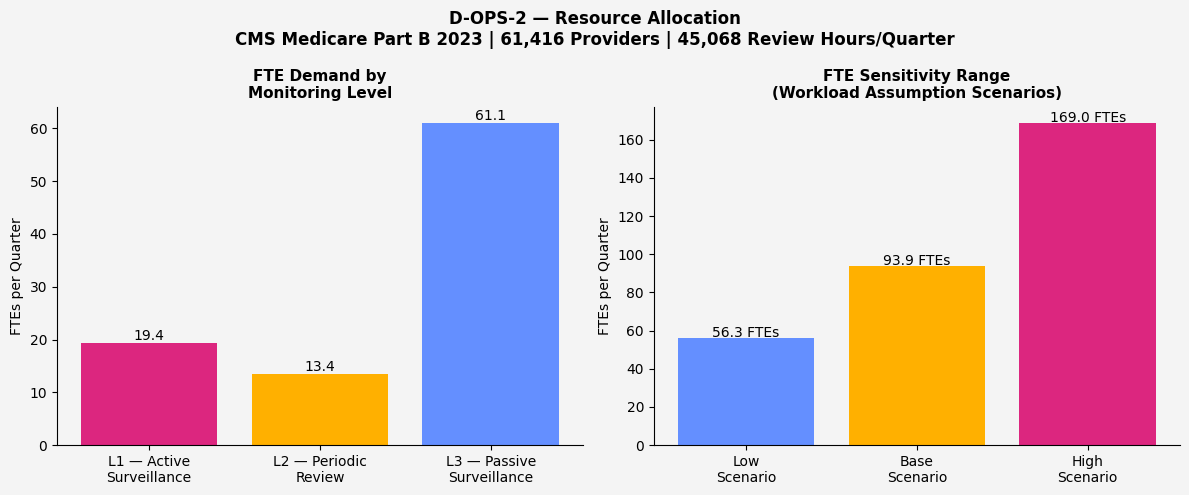

Figure saved.


In [25]:
# KAGNB-03-MODULES-30
# D-OPS-2 — Resource Allocation visualization

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

level_labels_short = ['L1 — Active\nSurveillance', 'L2 — Periodic\nReview', 'L3 — Passive\nSurveillance']
fte_values         = [dops2_l1_fte, dops2_l2_fte, dops2_l3_fte]
level_colors       = [PALETTE['tier1_oig'], PALETTE['tier2_tpe'], PALETTE['tier3_edletter']]

# Left — FTE demand by level
bars1 = axes[0].bar(level_labels_short, fte_values, color=level_colors)
for bar, val in zip(bars1, fte_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}', ha='center', fontsize=10)
axes[0].set_title('FTE Demand by\nMonitoring Level', fontsize=11, fontweight='bold')
axes[0].set_ylabel('FTEs per Quarter', fontsize=10)
axes[0].set_facecolor(PALETTE['background'])
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Right — sensitivity range
scenarios      = ['Low\nScenario', 'Base\nScenario', 'High\nScenario']
scenario_ftes  = [dops2_low_fte, dops2_base_fte, dops2_high_fte]
scenario_colors = [PALETTE['tier3_edletter'], PALETTE['tier2_tpe'], PALETTE['tier1_oig']]

bars2 = axes[1].bar(scenarios, scenario_ftes, color=scenario_colors)
for bar, val in zip(bars2, scenario_ftes):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f} FTEs', ha='center', fontsize=10)
axes[1].set_title('FTE Sensitivity Range\n(Workload Assumption Scenarios)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('FTEs per Quarter', fontsize=10)
axes[1].set_facecolor(PALETTE['background'])
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

fig.patch.set_facecolor(PALETTE['background'])
fig.suptitle('D-OPS-2 — Resource Allocation\nCMS Medicare Part B 2023 | 61,416 Providers | 45,068 Review Hours/Quarter',
             fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'kagnb_dops2_resource_allocation_v1.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")

<!-- KAGNB-03-MODULES-31 -->
#### Key Output

| Metric | Value | Tag |
|---|---|---|
| L1 FTE demand | 19.4 FTEs/quarter | D |
| L2 FTE demand | 13.4 FTEs/quarter | D |
| L3 FTE demand | 61.1 FTEs/quarter | D |
| Base total FTE demand | 93.9 FTEs/quarter | D |
| Total review hours | 45,068.5 hours/quarter | D |
| Sensitivity range (low) | 56.3 FTEs | A |
| Sensitivity range (high) | 169.0 FTEs | A |

> **Note on FTE interpretation:** The base estimate of 93.9 FTEs per quarter reflects workload assumptions applied to the D-OPS-1 monitoring roster. This is an analytical signal — not a staffing recommendation or budget request. The Decision Owner uses this output to inform resource planning conversations, not to directly determine headcount.

> **Note on sensitivity range:** The low and high scenarios reflect the uncertainty inherent in workload assumptions. Review hours per provider, case complexity, and organizational capacity all vary. The 56.3 — 169.0 FTE range is intentionally wide to surface that uncertainty honestly rather than present false precision. All sensitivity assumptions are parameterized in the D-OPS-2 CONFIG cell and subject to quarterly calibration review.

> **Note on L3 FTE dominance:** L3 Passive Surveillance drives 61.1 of the 93.9 base FTEs because it contains 58,641 providers. Even at low review hours per provider, volume drives the workload. This is an operational design consideration — the Decision Owner may elect to adjust L3 review frequency to manage total FTE demand.

#### Uncertainty Notice
FTE estimates are derived from workload assumptions reflecting analytical judgment. Actual staffing requirements depend on organizational capacity, case complexity, and operational priorities. No output constitutes a budget recommendation. All assumptions are parameterized and subject to quarterly calibration review.

<!-- KAGNB-03-MODULES-32 -->
### Module 7 of 7 — D-EXT-1: Safe Reporting

| | |
|---|---|
| **Domain** | External Reporting |
| **Decision Owner** | Compliance Officer / OIG Hotline Coordination Lead |
| **Operational Question** | Which providers meet the threshold for external reporting consideration and how can that output be prepared safely? |
| **Action Informed** | Prepare safe, compliance-ready output for external reporting coordination |

#### Analytical Approach

D-EXT-1 is the final module in the framework. It takes providers from the D-PI-2 OIG/DOJ Referral pathway and prepares a compliance-ready output file suitable for external reporting coordination. The module applies three safety layers before any output is written:

| Safety Layer | Description |
|---|---|
| Threshold filter | Only providers meeting minimum signal and dollar thresholds are included |
| Field restriction | Output contains only fields appropriate for external reporting — no exploratory or intermediate fields |
| Disclaimer attachment | Every output record carries an explicit disclaimer that the output is analytical only and does not constitute a referral |

The output is designed to be handed directly to the Compliance Officer or OIG Hotline Coordination Lead without further preparation. Safety is the primary design constraint of this module.

#### Uncertainty Notice
D-EXT-1 output does not constitute an OIG referral, a fraud referral, or any finding of wrongdoing. It is a compliance-ready analytical output prepared for Decision Owner review. All reporting decisions rest entirely with the Decision Owner.

In [26]:
# KAGNB-03-MODULES-33
# D-EXT-1 — Safe Reporting
# Load and derive key output figures

df_safe_providers = pd.read_parquet(PROCESSED_DIR / 'safe_reporting_providers_v1.parquet')
df_safe_summary   = pd.read_parquet(PROCESSED_DIR / 'safe_reporting_summary_v1.parquet')

print("=== D-EXT-1 FILES LOADED ===")
print(f"safe_reporting_providers_v1 — rows: {len(df_safe_providers):,}")
print(f"safe_reporting_summary_v1   — rows: {len(df_safe_summary):,}")
print()

print("=== COLUMN CHECK — safe_reporting_providers_v1 ===")
print(df_safe_providers.columns.tolist())
print()

print("=== COLUMN CHECK — safe_reporting_summary_v1 ===")
print(df_safe_summary.columns.tolist())
print()

print("=== SAMPLE — safe_reporting_summary_v1 ===")
print(df_safe_summary)

=== D-EXT-1 FILES LOADED ===
safe_reporting_providers_v1 — rows: 3,182
safe_reporting_summary_v1   — rows: 5

=== COLUMN CHECK — safe_reporting_providers_v1 ===
['Rndrng_NPI', 'Rndrng_Prvdr_Type', 'Rndrng_Prvdr_State_Abrvtn', 'pathway', 'monitoring_level', 'allowed_dollars_sum', 'composite_score', 'disclaimer', 'evidence_tag']

=== COLUMN CHECK — safe_reporting_summary_v1 ===
['pathway', 'monitoring_level', 'provider_count', 'total_allowed', 'mean_composite', 'pct_providers', 'pct_dollars', 'evidence_tag', 'disclaimer', 'total_allowed_M']

=== SAMPLE — safe_reporting_summary_v1 ===
                      pathway                monitoring_level  provider_count  \
0            OIG/DOJ Referral   Level 1 — Active Surveillance             606   
1            OIG/DOJ Referral       Level 2 — Periodic Review              49   
2  Targeted Probe and Educate   Level 1 — Active Surveillance             556   
3  Targeted Probe and Educate       Level 2 — Periodic Review            1564   
4  Tar

In [27]:
# KAGNB-03-MODULES-34
# D-EXT-1 — Derive safe reporting key figures

dext1_total_providers = len(df_safe_providers)
dext1_total_allowed   = df_safe_providers['allowed_dollars_sum'].sum()

# By pathway
dext1_oig_count    = (df_safe_providers['pathway'] == 'OIG/DOJ Referral').sum()
dext1_tpe_count    = (df_safe_providers['pathway'] == 'Targeted Probe and Educate').sum()

dext1_oig_allowed  = df_safe_providers.loc[df_safe_providers['pathway'] == 'OIG/DOJ Referral', 'allowed_dollars_sum'].sum()
dext1_tpe_allowed  = df_safe_providers.loc[df_safe_providers['pathway'] == 'Targeted Probe and Educate', 'allowed_dollars_sum'].sum()

# Disclaimer confirmation
disclaimer_present = df_safe_providers['disclaimer'].notna().all()
evidence_tags      = df_safe_providers['evidence_tag'].unique().tolist()

print("=== D-EXT-1: SAFE REPORTING ===")
print(f"Total providers in safe output     : {dext1_total_providers:,}")
print(f"Total allowed dollars              : ${dext1_total_allowed/1_000_000:,.1f}M")
print()
print(f"OIG/DOJ Referral pathway           : {dext1_oig_count:,} providers | ${dext1_oig_allowed/1_000_000:,.1f}M")
print(f"Targeted Probe and Educate pathway : {dext1_tpe_count:,} providers | ${dext1_tpe_allowed/1_000_000:,.1f}M")
print()
print(f"Disclaimer present on all records  : {disclaimer_present}")
print(f"Evidence tags present              : {evidence_tags}")

=== D-EXT-1: SAFE REPORTING ===
Total providers in safe output     : 3,182
Total allowed dollars              : $798.6M

OIG/DOJ Referral pathway           : 655 providers | $369.5M
Targeted Probe and Educate pathway : 2,527 providers | $429.0M

Disclaimer present on all records  : True
Evidence tags present              : ['D']


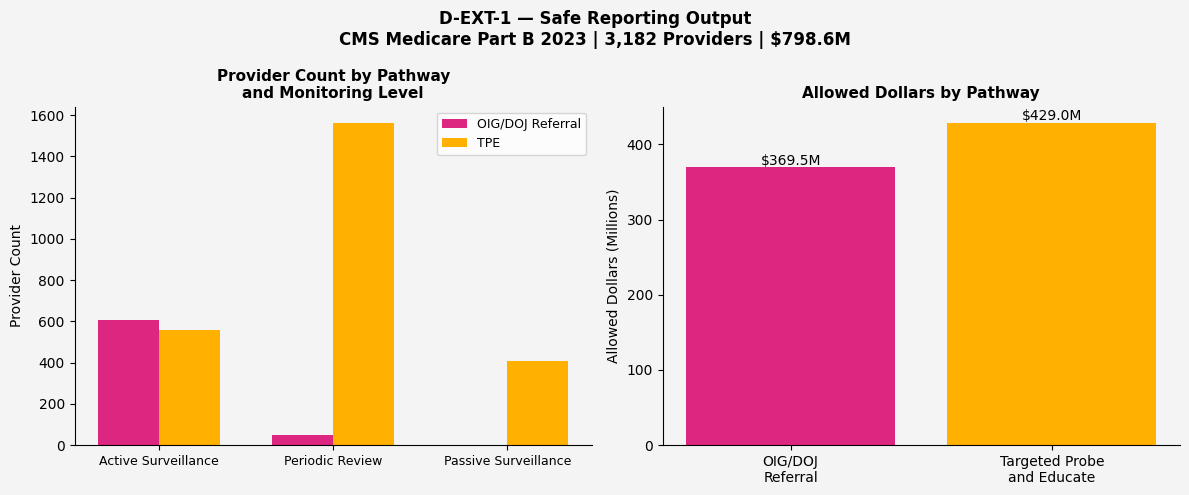

Figure saved.


In [28]:
# KAGNB-03-MODULES-35
# D-EXT-1 — Safe Reporting visualization

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left — provider count by pathway and monitoring level
pivot_count = df_safe_summary.pivot_table(
    index='monitoring_level',
    columns='pathway',
    values='provider_count',
    aggfunc='sum'
).fillna(0)

level_order = ['Level 1 — Active Surveillance',
               'Level 2 — Periodic Review',
               'Level 3 — Passive Surveillance']
pivot_count = pivot_count.reindex([l for l in level_order if l in pivot_count.index])

x = range(len(pivot_count))
width = 0.35
labels_short = [l.split(' — ')[1] for l in pivot_count.index]

bars_oig = axes[0].bar([i - width/2 for i in x],
                        pivot_count.get('OIG/DOJ Referral', 0),
                        width, label='OIG/DOJ Referral',
                        color=PALETTE['tier1_oig'])
bars_tpe = axes[0].bar([i + width/2 for i in x],
                        pivot_count.get('Targeted Probe and Educate', 0),
                        width, label='TPE',
                        color=PALETTE['tier2_tpe'])

axes[0].set_xticks(list(x))
axes[0].set_xticklabels(labels_short, fontsize=9)
axes[0].set_title('Provider Count by Pathway\nand Monitoring Level', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Provider Count', fontsize=10)
axes[0].legend(fontsize=9)
axes[0].set_facecolor(PALETTE['background'])
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Right — allowed dollars by pathway
pathway_labels  = ['OIG/DOJ\nReferral', 'Targeted Probe\nand Educate']
pathway_dollars = [dext1_oig_allowed/1_000_000, dext1_tpe_allowed/1_000_000]
pathway_colors  = [PALETTE['tier1_oig'], PALETTE['tier2_tpe']]

bars2 = axes[1].bar(pathway_labels, pathway_dollars, color=pathway_colors)
for bar, val in zip(bars2, pathway_dollars):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 f'${val:,.1f}M', ha='center', fontsize=10)
axes[1].set_title('Allowed Dollars by Pathway', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Allowed Dollars (Millions)', fontsize=10)
axes[1].set_facecolor(PALETTE['background'])
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

fig.patch.set_facecolor(PALETTE['background'])
fig.suptitle('D-EXT-1 — Safe Reporting Output\nCMS Medicare Part B 2023 | 3,182 Providers | $798.6M',
             fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'kagnb_dext1_safe_reporting_v1.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")

<!-- KAGNB-03-MODULES-36 -->
#### Key Output

| Metric | Value | Tag |
|---|---|---|
| Total providers in safe output | 3,182 | D |
| Total allowed dollars | $798.6M | D |
| OIG/DOJ Referral pathway | 655 providers — $369.5M | D |
| Targeted Probe and Educate pathway | 2,527 providers — $429.0M | D |
| Disclaimer present on all records | Yes — every record | D |
| Evidence tag on all records | D — Derived | D |

> **Note on safe output design:** D-EXT-1 is the only module in this framework that produces an output file intended for external use. Every design decision in this module prioritizes safety over completeness. Fields are restricted to what is appropriate for external reporting coordination. The disclaimer is embedded at the record level — not as a document header — so it travels with the data regardless of how the output is subsequently used.

> **Note on pathway scope:** The safe output includes both OIG/DOJ Referral and TPE pathway providers. TPE is included because Targeted Probe and Educate is an external-facing CMS program requiring coordination beyond the internal monitoring roster. Both pathways warrant Compliance Officer awareness.

> **Note on monitoring level distribution:** The left panel shows that TPE providers are concentrated in Periodic Review (L2) — 1,564 of 2,527. OIG providers are concentrated in Active Surveillance (L1) — 606 of 655. This alignment between pathway assignment and monitoring intensity is expected and reflects consistent scoring logic across D-PI-2 and D-OPS-1.

#### Uncertainty Notice
D-EXT-1 output does not constitute an OIG referral, a fraud referral, or any finding of wrongdoing. It is a compliance-ready analytical output prepared for Decision Owner review. All reporting decisions rest entirely with the Compliance Officer / OIG Hotline Coordination Lead.

<!-- KAGNB-04-SUMMARY-00 -->
## Section 04 — Framework Summary

This section presents a consolidated view of all seven decision modules. Each module addressed a specific operational question, delivered a specific analytical signal, and was designed for a named Decision Owner. No module output constitutes a decision. Every output informs human judgment.

The framework covers 970,848 Medicare Part B providers representing $66.81B in allowed dollars for Data Year 2023.

In [29]:
# KAGNB-04-SUMMARY-01
# Framework summary table — all 7 modules, derived from loaded dataframes

summary_data = {
    'Module': [
        'D-PI-1', 'D-PI-2', 'D-POL-1', 'D-POL-2',
        'D-OPS-1', 'D-OPS-2', 'D-EXT-1'
    ],
    'Decision': [
        'Provider Review Entry',
        'Escalation Threshold',
        'Code Scrutiny',
        'Specialty Pattern Shift',
        'Monitoring Placement',
        'Resource Allocation',
        'Safe Reporting'
    ],
    'Decision Owner': [
        'Investigations Lead / PI Analytics Manager',
        'Investigations Lead / UPIC Case Dev. Manager',
        'Medical Review Director / MAC Medical Director',
        'Medical Review Director / CPI Policy Analyst',
        'UPIC Operations Manager / CPI Monitoring Lead',
        'CPI Director / PI Resource Manager',
        'Compliance Officer / OIG Hotline Coord. Lead'
    ],
    'Key Output': [
        f'{dpi1_tier1_count:,} Tier 1 providers | ${dpi1_tier1_allowed/1_000_000_000:.2f}B',
        f'{dpi2_oig_count:,} OIG | {dpi2_tpe_count:,} TPE | {dpi2_edletter_count:,} Ed. Letters',
        f'{dpol1_all_three:,} providers | {dpol1_unique_codes:,} codes flagged',
        f'{dpol2_flagged_specialties:,} specialties flagged | {dpol2_both_dimensions:,} both dimensions',
        f'L1: {dops1_l1:,} | L2: {dops1_l2:,} | L3: {dops1_l3:,} providers',
        f'Base: {dops2_base_fte:.1f} FTEs/quarter | Range: {dops2_low_fte:.1f}—{dops2_high_fte:.1f}',
        f'{dext1_total_providers:,} providers | ${dext1_total_allowed/1_000_000:.1f}M'
    ]
}

df_summary = pd.DataFrame(summary_data)

print("=== FRAMEWORK SUMMARY ===")
print(df_summary.to_string(index=False))

=== FRAMEWORK SUMMARY ===
 Module                Decision                                 Decision Owner                                   Key Output
 D-PI-1   Provider Review Entry     Investigations Lead / PI Analytics Manager             22,400 Tier 1 providers | $4.29B
 D-PI-2    Escalation Threshold   Investigations Lead / UPIC Case Dev. Manager     655 OIG | 2,527 TPE | 19,218 Ed. Letters
D-POL-1           Code Scrutiny Medical Review Director / MAC Medical Director          554 providers | 1,012 codes flagged
D-POL-2 Specialty Pattern Shift   Medical Review Director / CPI Policy Analyst   74 specialties flagged | 3 both dimensions
D-OPS-1    Monitoring Placement  UPIC Operations Manager / CPI Monitoring Lead L1: 1,162 | L2: 1,613 | L3: 58,641 providers
D-OPS-2     Resource Allocation             CPI Director / PI Resource Manager  Base: 93.9 FTEs/quarter | Range: 56.3—169.0
D-EXT-1          Safe Reporting   Compliance Officer / OIG Hotline Coord. Lead                    3,182 pr

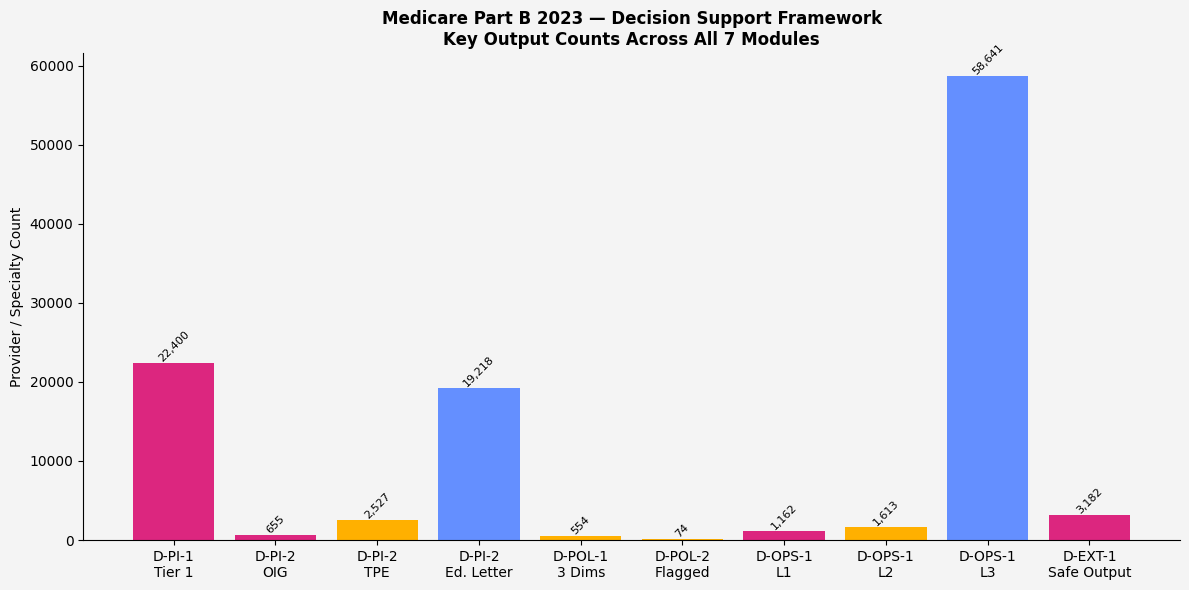

Figure saved.


In [30]:
# KAGNB-04-SUMMARY-02
# Framework summary visualization — provider counts across all modules

fig, ax = plt.subplots(figsize=(12, 6))

modules = ['D-PI-1\nTier 1', 'D-PI-2\nOIG', 'D-PI-2\nTPE', 'D-PI-2\nEd. Letter',
           'D-POL-1\n3 Dims', 'D-POL-2\nFlagged', 'D-OPS-1\nL1',
           'D-OPS-1\nL2', 'D-OPS-1\nL3', 'D-EXT-1\nSafe Output']

counts = [
    dpi1_tier1_count,
    dpi2_oig_count,
    dpi2_tpe_count,
    dpi2_edletter_count,
    dpol1_all_three,
    dpol2_flagged_specialties,
    dops1_l1,
    dops1_l2,
    dops1_l3,
    dext1_total_providers
]

colors = [
    PALETTE['tier1_oig'],
    PALETTE['tier1_oig'],
    PALETTE['tier2_tpe'],
    PALETTE['tier3_edletter'],
    PALETTE['tier2_tpe'],
    PALETTE['tier2_tpe'],
    PALETTE['tier1_oig'],
    PALETTE['tier2_tpe'],
    PALETTE['tier3_edletter'],
    PALETTE['tier1_oig']
]

bars = ax.bar(modules, counts, color=colors)
for bar, val in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}', ha='center', fontsize=8, rotation=45)

ax.set_ylabel('Provider / Specialty Count', fontsize=10)
ax.set_title('Medicare Part B 2023 — Decision Support Framework\nKey Output Counts Across All 7 Modules',
             fontsize=12, fontweight='bold')
ax.set_facecolor(PALETTE['background'])
fig.patch.set_facecolor(PALETTE['background'])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'kagnb_framework_summary_v1.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")

<!-- KAGNB-04-SUMMARY-03 -->
### Framework Summary — Decision Owner Reference

| Module | Domain | Decision Owner | Key Output | Tag |
|---|---|---|---|---|
| D-PI-1 | Program Integrity | Investigations Lead / PI Analytics Manager | 22,400 Tier 1 providers — $4.29B | D |
| D-PI-2 | Program Integrity | Investigations Lead / UPIC Case Dev. Manager | 655 OIG — 2,527 TPE — 19,218 Ed. Letters | D |
| D-POL-1 | Policy | Medical Review Director / MAC Medical Director | 554 providers — 1,012 codes flagged | D |
| D-POL-2 | Policy | Medical Review Director / CPI Policy Analyst | 74 specialties flagged — 3 both dimensions | D |
| D-OPS-1 | Operations | UPIC Operations Manager / CPI Monitoring Lead | L1: 1,162 — L2: 1,613 — L3: 58,641 | D |
| D-OPS-2 | Operations | CPI Director / PI Resource Manager | 93.9 FTEs/quarter — range 56.3—169.0 | D |
| D-EXT-1 | External Reporting | Compliance Officer / OIG Hotline Coord. Lead | 3,182 providers — $798.6M | D |

### Design Principles

Every module in this framework was built on four non-negotiable principles:

**1. Named Decision Owners.** Every analytical output is addressed to a specific operational role. Analytics without a named recipient is not decision support — it is data production.

**2. No assertions of wrongdoing.** No output in this framework asserts provider intent, fraud, waste, or abuse. Signals describe statistical patterns. Decisions belong to humans.

**3. Parameterized assumptions.** Every threshold, weight, and scoring parameter is documented with rationale and subject to quarterly calibration review. No hardcoded values anywhere in the framework.

**4. Evidence tagging throughout.** Every output carries O/D/I/A tags — Observed, Derived, Inferred, Assumed — so Decision Owners understand the epistemic basis of every figure they receive.

### Full Implementation

The complete framework — all notebooks, decision charters, evidence logs, decision logs, and companion documents — is available at:

**https://github.com/billmarmcswss/medicare-integrity-decision-support**

Data source: CMS Medicare Part B Provider and Services Public Use File, Release Year 2025, Data Year 2023 (RY25/D23).
All data publicly available from the Centers for Medicare and Medicaid Services.

<!-- KAGNB-05-EVIDENCE-00 -->
## Section 05 — Evidence Log

This evidence log summarizes the analytical basis for key outputs presented in this notebook. All entries follow the O/D/I/A evidence tagging standard used throughout the framework:

| Tag | Meaning | Description |
|---|---|---|
| O | Observed | Directly read from source data without transformation |
| D | Derived | Computed from source data through documented logic |
| I | Inferred | Interpreted from patterns — judgment involved |
| A | Assumed | Analytical assumption — not derived from data |

All evidence entries below correspond to outputs presented in this notebook. Full evidence logs for each module are available in the GitHub repository under each module's decision folder.

In [31]:
# KAGNB-05-EVIDENCE-01
# Evidence log — framework-level summary entries
# O/D/I/A tagged throughout
# All values derived from variables — no hardcoded numbers

total_providers      = len(df_tiered)
total_allowed_B      = df_tiered['allowed_dollars_sum'].sum() / 1_000_000_000

evidence_entries = [
    {
        'Entry': 'E-KAGNB-01',
        'Module': 'Framework',
        'Tag': 'O',
        'Description': f'Total provider population of {total_providers:,} read directly from CMS Medicare Part B PUF RY25/D23 via df_tiered row count.'
    },
    {
        'Entry': 'E-KAGNB-02',
        'Module': 'Framework',
        'Tag': 'O',
        'Description': f'Total allowed dollars of ${total_allowed_B:,.2f}B summed directly from allowed_dollars_sum column in df_tiered. No transformation applied.'
    },
    {
        'Entry': 'E-KAGNB-03',
        'Module': 'D-PI-1',
        'Tag': 'D',
        'Description': f'Tier 1 provider count of {dpi1_tier1_count:,} and allowed dollars of ${dpi1_tier1_allowed/1_000_000_000:.2f}B derived by filtering df_tiered on anomaly_tier == Tier1_Review.'
    },
    {
        'Entry': 'E-KAGNB-04',
        'Module': 'D-PI-1',
        'Tag': 'D',
        'Description': 'Active review queue of 500 providers representing $1.77B reported from D-PI-1 notebook decision output cell. Queue is top 500 providers by composite score from the 22,400 Tier 1 population. Sized to operational review capacity.'
    },
    {
        'Entry': 'E-KAGNB-05',
        'Module': 'D-PI-2',
        'Tag': 'D',
        'Description': f'Pathway counts — {dpi2_oig_count:,} OIG, {dpi2_tpe_count:,} TPE, {dpi2_edletter_count:,} Education Letters — derived from pathway column in escalation_pathway_v1.parquet.'
    },
    {
        'Entry': 'E-KAGNB-06',
        'Module': 'D-PI-2',
        'Tag': 'D',
        'Description': f'Pathway allowed dollars — OIG ${dpi2_oig_allowed/1_000_000_000:.2f}B, TPE ${dpi2_tpe_allowed/1_000_000_000:.2f}B, Ed. Letter ${dpi2_edletter_allowed/1_000_000_000:.2f}B — derived by grouping escalation_pathway_v1 on pathway and summing allowed_dollars_sum.'
    },
    {
        'Entry': 'E-KAGNB-07',
        'Module': 'D-POL-1',
        'Tag': 'D',
        'Description': f'{dpol1_all_three:,} providers with all three active dimensions firing derived by filtering code_scrutiny_flags_v1 on dimensions_flagged >= 3.'
    },
    {
        'Entry': 'E-KAGNB-08',
        'Module': 'D-POL-1',
        'Tag': 'D',
        'Description': f'{dpol1_unique_codes:,} unique HCPCS codes flagged derived from nunique() on HCPCS_Cd column in top_codes_by_frequency_v1.parquet.'
    },
    {
        'Entry': 'E-KAGNB-09',
        'Module': 'D-POL-2',
        'Tag': 'D',
        'Description': f'{dpol2_flagged_specialties:,} specialties flagged derived from row count of specialty_pattern_flags_v1.parquet. {dpol2_both_dimensions:,} specialties with both dimensions firing derived by filtering on dimensions_flagged >= 2.'
    },
    {
        'Entry': 'E-KAGNB-10',
        'Module': 'D-OPS-1',
        'Tag': 'D',
        'Description': f'Monitoring level counts — L1: {dops1_l1:,}, L2: {dops1_l2:,}, L3: {dops1_l3:,} — derived from monitoring_level column in monitoring_roster_v1.parquet using exact string labels.'
    },
    {
        'Entry': 'E-KAGNB-11',
        'Module': 'D-OPS-2',
        'Tag': 'D',
        'Description': f'Base FTE demand of {dops2_base_fte:.1f} FTEs/quarter derived by summing fte_demand column in resource_level_summary_v1.parquet across all three monitoring levels.'
    },
    {
        'Entry': 'E-KAGNB-12',
        'Module': 'D-OPS-2',
        'Tag': 'A',
        'Description': f'Sensitivity range low ({dops2_low_fte:.1f} FTEs) and high ({dops2_high_fte:.1f} FTEs) derived by applying 0.60 and 1.80 multipliers to base FTE estimate. Multipliers reflect workload assumption uncertainty — analytical judgment.'
    },
    {
        'Entry': 'E-KAGNB-13',
        'Module': 'D-EXT-1',
        'Tag': 'D',
        'Description': f'{dext1_total_providers:,} providers and ${dext1_total_allowed/1_000_000:.1f}M derived from safe_reporting_providers_v1.parquet row count and allowed_dollars_sum. Disclaimer confirmed present on all records via notna() check.'
    },
]

df_evidence = pd.DataFrame(evidence_entries)

print("=== EVIDENCE LOG — KAGNB ===")
print(f"Total entries: {len(df_evidence)}")
print()
print(df_evidence[['Entry', 'Module', 'Tag', 'Description']].to_string(index=False))

=== EVIDENCE LOG — KAGNB ===
Total entries: 13

     Entry    Module Tag                                                                                                                                                                                                                         Description
E-KAGNB-01 Framework   O                                                                                                                   Total provider population of 970,848 read directly from CMS Medicare Part B PUF RY25/D23 via df_tiered row count.
E-KAGNB-02 Framework   O                                                                                                           Total allowed dollars of $66.81B summed directly from allowed_dollars_sum column in df_tiered. No transformation applied.
E-KAGNB-03    D-PI-1   D                                                                                                       Tier 1 provider count of 22,400 and allowed dollars of $4.29B deri

<!-- KAGNB-05-EVIDENCE-02 -->
### Evidence Log — Completeness Notice

This evidence log covers the 13 key analytical outputs presented in this notebook. It does not replace the module-level evidence logs maintained in the GitHub repository — each of the seven decision modules carries its own full evidence log documenting every cell-level output in detail.

**Full evidence logs by module:**

| Module | Evidence Log Location |
|---|---|
| D-PI-1 | decisions/D-PI-1_provider_review/evidence_log.md |
| D-PI-2 | decisions/D-PI-2_escalation_threshold/evidence_log.md |
| D-POL-1 | decisions/D-POL-1_code_scrutiny/evidence_log.md |
| D-POL-2 | decisions/D-POL-2_specialty_shift/evidence_log.md |
| D-OPS-1 | decisions/D-OPS-1_monitoring_placement/evidence_log.md |
| D-OPS-2 | decisions/D-OPS-2_resource_allocation/evidence_log.md |
| D-EXT-1 | decisions/D-EXT-1_safe_reporting/evidence_log.md |

All evidence logs are available at:
**https://github.com/billmarmcswss/medicare-integrity-decision-support**

---
*This notebook was produced using CMS Medicare Part B Provider and Services Public Use File, Release Year 2025, Data Year 2023 (RY25/D23). All data publicly available from the Centers for Medicare and Medicaid Services. No provider is identified by name in any output. No output asserts fraud, waste, or abuse.*